# Etapa 1. Conociendo el negocio
## PARTE 2. COMPRENSIÓN Y PREPARACIÓN DE LOS DATOS
### Alberto José Corella Moreno | A01255649
### Josué Uziel Ocañas Hernández | A01384725
### Javier Ogueta Burgaleta | A01833375
### 20/08/2026


## 1) Comprensión de los datos

In [ ]:
import pandas as pd
import numpy as np
import os

# Bases de datos
files = ["BD 2020.xlsx", "BD 2021.xlsx", "BD 2022.xlsx", "BD 2023.xlsx", "BD 2024.xlsx", "BD 2025.xlsx"]

# Rangos de los parámetros de SIMA para cada contaminante en cada año
valid_ranges = {
    2020: {'PM10': (0,800), 'PM2.5': (0,205.94), 'O3': (0,153), 'NO': (0,500), 'NO2': (0,200), 'NOX': (0,500), 'SO2': (0,200), 'CO': (0,20), 'RH': (0,100), 'WS': (0,75), 'TEMP': (0,41), 'SR': (0,1), 'BP': (690,750), 'WD': (0,360), 'RAINF': (0,30)},
    2021: {'PM10': (0,800), 'PM2.5': (0,325), 'O3': (0,175), 'NO': (0,350), 'NO2': (0,100), 'NOX': (0,400), 'SO2': (0,300), 'CO': (0,10), 'RH': (0,100), 'WS': (0,40), 'TEMP': (-6.5,45), 'SR': (0,1), 'BP': (690,740), 'WD': (0,360), 'RAINF': (0,80)},
    2022: {'PM10': (0,999), 'PM2.5': (0,450), 'O3': (0,160), 'NO': (0,400), 'NO2': (0,175), 'NOX': (0,420), 'SO2': (0,200), 'CO': (0,8), 'RH': (0,100), 'WS': (0,35), 'TEMP': (-5,45), 'SR': (0,1.25), 'BP': (700,740), 'WD': (0,360), 'RAINF': (0,25)},
    2023: {'PM10': (0,900), 'PM2.5': (0,800), 'O3': (0,175), 'NO': (0,500), 'NO2': (0,175), 'NOX': (0,500), 'SO2': (0,250), 'CO': (0,14), 'RH': (0,100), 'WS': (0,40), 'TEMP': (0,45), 'SR': (0,1), 'BP': (690,740), 'WD': (0,360), 'RAINF': (0,70)},
    2024: {'PM10': (0,999), 'PM2.5': (0,999), 'O3': (0,180), 'NO': (0,400), 'NO2': (0,130), 'NOX': (0,500), 'SO2': (0,150), 'CO': (0,18), 'RH': (0,100), 'WS': (0,38), 'TEMP': (-4,45.5), 'SR': (0,1.26), 'BP': (687.5,740), 'WD': (0,360), 'RAINF': (0,50)},
    2025: {'PM10': (0,820), 'PM2.5': (0,350), 'O3': (0,185), 'NO': (0,350), 'NO2': (0,175), 'NOX': (0,400), 'SO2': (0,405), 'CO': (0,10), 'RH': (0,100), 'WS': (0,40), 'TEMP': (-4.5,45), 'SR': (0,1.2), 'BP': (688,740), 'WD': (0,360), 'RAINF': (0,25)}
}

# Mapa para estandarizar las columnas meteorológicas
col_map = {'PRS': 'BP', 'TOUT': 'TEMP', 'WSR': 'WS', 'WDR': 'WD'}

# Inicializar el diccionario anidado que contendrá todos los DataFrames
datos_sima = {}

### 2) Preparación de los datos

In [ ]:
# PROCESAMIENTO, LIMPIEZA E IMPUTACIÓN DE DATOS
for f in files:
    if os.path.exists(f):
        year = int(f.split(' ')[1].split('.')[0])
        datos_sima[year] = {}

        xls = pd.ExcelFile(f)
        estaciones = xls.sheet_names
        print(f"Procesando {year}... {len(estaciones)} estaciones detectadas.")

        for estacion in estaciones:
            # Leer la hoja específica
            df = pd.read_excel(xls, sheet_name=estacion)

            # Homologar la columna de fechas
            if 'date' in df.columns and 'Fecha y hora' in df.columns:
                df['Fecha'] = df['Fecha y hora'].combine_first(df['date'])
                df = df.drop(columns=['Fecha y hora', 'date'])
            elif 'Fecha y hora' in df.columns:
                df = df.rename(columns={'Fecha y hora': 'Fecha'})
            elif 'date' in df.columns:
                df = df.rename(columns={'date': 'Fecha'})

            # Renombrar variables meteorológicas
            df = df.rename(columns=col_map)

            # Asegurar formato datetime y orden cronológico
            if 'Fecha' in df.columns:
                df['Fecha'] = pd.to_datetime(df['Fecha'])
                df = df.sort_values('Fecha').reset_index(drop=True)

            # Limpiar duplicados
            df = df.drop_duplicates()

            # Tratamiento de valores espurios (volverlos nulos temporalmente)
            ranges = valid_ranges.get(year, {})
            for col, (vmin, vmax) in ranges.items():
                if col in df.columns:
                    out_of_bounds = (df[col] < vmin) | (df[col] > vmax)
                    df.loc[out_of_bounds, col] = np.nan

            # Imputación de datos numéricos
            numeric_cols = df.select_dtypes(include=[np.number]).columns

            # 1. Interpolar pequeños vacíos (máx 3 horas)
            df[numeric_cols] = df[numeric_cols].interpolate(method='linear', limit=3)

            # 2. Imputar con la mediana de la estación y año para vacíos extensos
            df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

            # Almacenar en la estructura
            datos_sima[year][estacion] = df

print("Procesamiento completado con éxito.")

Procesando 2020... 13 estaciones detectadas.
Procesando 2021... 14 estaciones detectadas.
Procesando 2022... 15 estaciones detectadas.
Procesando 2023... 15 estaciones detectadas.
Procesando 2024... 15 estaciones detectadas.
Procesando 2025... 15 estaciones detectadas.
Procesamiento completado con éxito.


Tamaño de la muestra analizada: 8760 registros.

--- Normalidad Univariada (D'Agostino's K-squared) ---
PM10: p-value = 0.00e+00 -> No Normal (Rechaza H0)
PM2.5: p-value = 0.00e+00 -> No Normal (Rechaza H0)
SO2: p-value = 0.00e+00 -> No Normal (Rechaza H0)
CO: p-value = 0.00e+00 -> No Normal (Rechaza H0)
NO: p-value = 0.00e+00 -> No Normal (Rechaza H0)
NO2: p-value = 0.00e+00 -> No Normal (Rechaza H0)
NOX: p-value = 0.00e+00 -> No Normal (Rechaza H0)
O3: p-value = 0.00e+00 -> No Normal (Rechaza H0)
TEMP: p-value = 3.38e-108 -> No Normal (Rechaza H0)
RH: p-value = 4.22e-126 -> No Normal (Rechaza H0)
WS: p-value = 2.36e-80 -> No Normal (Rechaza H0)
WD: p-value = 0.00e+00 -> No Normal (Rechaza H0)


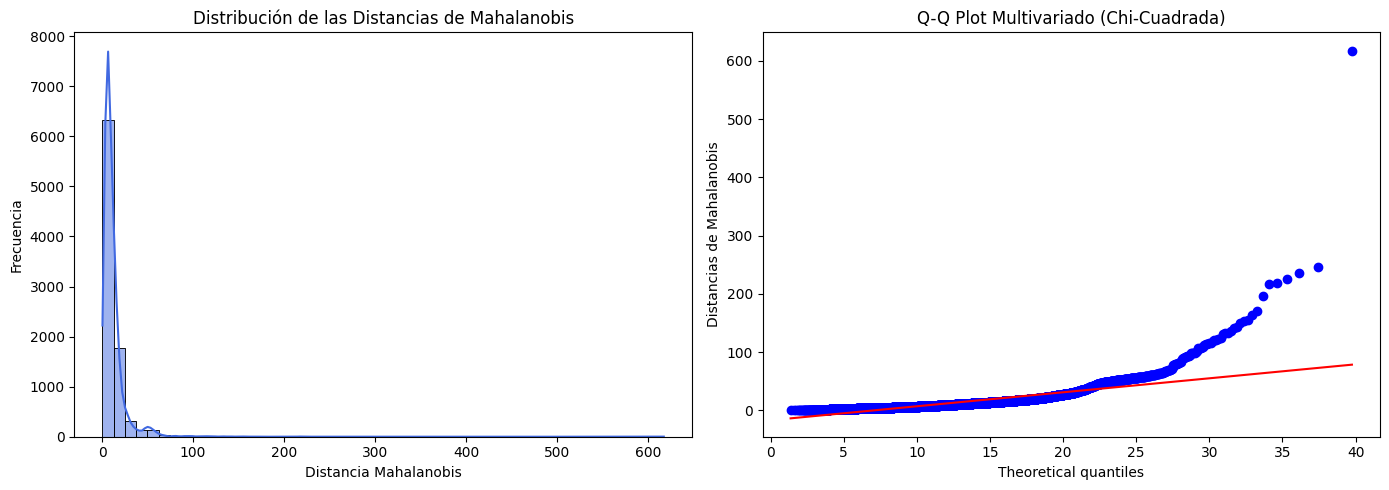

In [ ]:
# PRUEBAS DE NORMALIDAD (UNIVARIADA Y MULTIVARIADA)
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Seleccionar un DataFrame de ejemplo del diccionario (ej. Estación 'CE' en 2021)
año_prueba = 2021
estacion_prueba = 'CE'

if año_prueba in datos_sima and estacion_prueba in datos_sima[año_prueba]:
    df_prueba = datos_sima[año_prueba][estacion_prueba]

    # 1. PREPARACIÓN DE LOS DATOS
    # Seleccionar las variables contaminantes y meteorológicas de interés
    vars_to_test = ['PM10', 'PM2.5','SO2','CO','NO','NO2','NOX','O3','TEMP','RH','WS','WD']

    # Filtrar solo las variables que realmente existen en el DataFrame
    vars_to_test = [v for v in vars_to_test if v in df_prueba.columns]

    # Las pruebas multivariadas requieren casos completos, descartamos filas con nulos temporalmente
    df_clean = df_prueba[vars_to_test].dropna()
    print(f"Tamaño de la muestra analizada: {len(df_clean)} registros.\n")

    # 2. NORMALIDAD UNIVARIADA (Test de D'Agostino's K-squared)
    print("--- Normalidad Univariada (D'Agostino's K-squared) ---")
    for col in df_clean.columns:
        stat, p = stats.normaltest(df_clean[col])
        resultado = 'Normal' if p > 0.05 else 'No Normal (Rechaza H0)'
        print(f"{col}: p-value = {p:.2e} -> {resultado}")

    # 3. NORMALIDAD MULTIVARIADA (Distancias de Mahalanobis)
    # Calcular la matriz de covarianza y su inversa
    cov_matrix = np.cov(df_clean.values.T)
    inv_cov_matrix = np.linalg.inv(cov_matrix)
    mean_vec = np.mean(df_clean.values, axis=0)

    # Calcular las distancias de Mahalanobis para cada observación
    diff = df_clean.values - mean_vec
    md = np.zeros(len(df_clean))
    for i in range(len(df_clean)):
        md[i] = np.dot(np.dot(diff[i], inv_cov_matrix), diff[i].T)

    # 4. VISUALIZACIÓN
    df_chi2 = len(vars_to_test) # Grados de libertad = número de variables

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma de las Distancias
    sns.histplot(md, bins=50, kde=True, ax=axes[0], color='royalblue')
    axes[0].set_title('Distribución de las Distancias de Mahalanobis')
    axes[0].set_xlabel('Distancia Mahalanobis')
    axes[0].set_ylabel('Frecuencia')

    # Q-Q Plot Multivariado
    stats.probplot(md, dist=stats.chi2, sparams=(df_chi2,), plot=axes[1])
    axes[1].get_lines()[0].set_color('blue')  # Puntos
    axes[1].get_lines()[1].set_color('red')   # Línea teórica
    axes[1].set_title('Q-Q Plot Multivariado (Chi-Cuadrada)')
    axes[1].set_ylabel('Distancias de Mahalanobis')

    plt.tight_layout()
    plt.show()

else:
    print("La estación o el año seleccionado no se encuentran en los datos.")

In [ ]:
# =====================================================================
# MÉTRICAS DE PREPARACIÓN DE DATOS
# =====================================================================

vars_all = ['CO','NO','NO2','NOX','O3','PM10','PM2.5','BP','RAINF','RH','SO2','SR','TEMP','WS','WD']
stats_var = {v: {'total_celdas':0, 'nulos_originales':0, 'atipicos':0,
                  'nulos_post_atipicos':0, 'imputado_interp':0,
                  'imputado_mediana':0, 'nulos_sin_llenar':0} for v in vars_all}

total_filas_raw = 0
total_duplicados = 0
n_hojas = 0
filas_por_anio = {}
sensores_inactivos_100 = []  # (año, estación, variable) con 100% de nulos en esa hoja

for f in files:
    if not os.path.exists(f):
        continue
    year = int(f.split(' ')[1].split('.')[0])
    xls = pd.ExcelFile(f)
    estaciones = xls.sheet_names
    n_hojas += len(estaciones)
    filas_year = 0

    for estacion in estaciones:
        df = pd.read_excel(xls, sheet_name=estacion)

        # Homologar fecha (igual que en el procesamiento principal)
        if 'date' in df.columns and 'Fecha y hora' in df.columns:
            df['Fecha'] = df['Fecha y hora'].combine_first(df['date'])
            df = df.drop(columns=['Fecha y hora', 'date'])
        elif 'Fecha y hora' in df.columns:
            df = df.rename(columns={'Fecha y hora': 'Fecha'})
        elif 'date' in df.columns:
            df = df.rename(columns={'date': 'Fecha'})

        df = df.rename(columns=col_map)

        if 'Fecha' in df.columns:
            df['Fecha'] = pd.to_datetime(df['Fecha'])
            df = df.sort_values('Fecha').reset_index(drop=True)

        # --- Duplicados ---
        n_antes_dup = len(df)
        df = df.drop_duplicates()
        total_duplicados += (n_antes_dup - len(df))
        total_filas_raw += n_antes_dup
        filas_year += n_antes_dup

        numeric_cols = df.select_dtypes(include=[np.number]).columns

        # --- Nulos originales por variable ---
        for col in numeric_cols:
            if col not in stats_var:
                continue
            stats_var[col]['total_celdas'] += len(df)
            stats_var[col]['nulos_originales'] += df[col].isnull().sum()
            if df[col].isnull().mean() == 1.0:
                sensores_inactivos_100.append((year, estacion, col))

        # --- Atípicos (valores fuera de rango SIMA -> NaN) ---
        ranges = valid_ranges.get(year, {})
        for col, (vmin, vmax) in ranges.items():
            if col in df.columns:
                out_of_bounds = (df[col] < vmin) | (df[col] > vmax)
                stats_var[col]['atipicos'] += out_of_bounds.sum()
                df.loc[out_of_bounds, col] = np.nan

        for col in numeric_cols:
            if col not in stats_var:
                continue
            stats_var[col]['nulos_post_atipicos'] += df[col].isnull().sum()

        # --- Imputación: interpolación (huecos cortos, <=3h) ---
        df_interp = df[numeric_cols].interpolate(method='linear', limit=3)
        for col in numeric_cols:
            if col not in stats_var:
                continue
            nulos_antes = df[col].isnull().sum()
            nulos_despues = df_interp[col].isnull().sum()
            stats_var[col]['imputado_interp'] += (nulos_antes - nulos_despues)

        # --- Imputación: mediana (huecos largos/residuales) ---
        medianas = df_interp.median()
        df_final = df_interp.fillna(medianas)
        for col in numeric_cols:
            if col not in stats_var:
                continue
            nulos_antes_mediana = df_interp[col].isnull().sum()
            nulos_despues_mediana = df_final[col].isnull().sum()
            stats_var[col]['imputado_mediana'] += (nulos_antes_mediana - nulos_despues_mediana)
            stats_var[col]['nulos_sin_llenar'] += nulos_despues_mediana

    filas_por_anio[year] = filas_year

# =====================================================================
# RESUMEN GLOBAL
# =====================================================================
total_celdas = sum(s['total_celdas'] for s in stats_var.values())
total_nulos_orig = sum(s['nulos_originales'] for s in stats_var.values())
total_atipicos = sum(s['atipicos'] for s in stats_var.values())
total_huecos = sum(s['nulos_post_atipicos'] for s in stats_var.values())
total_interp = sum(s['imputado_interp'] for s in stats_var.values())
total_mediana = sum(s['imputado_mediana'] for s in stats_var.values())
total_sin_llenar = sum(s['nulos_sin_llenar'] for s in stats_var.values())

print("="*72)
print("RESUMEN GLOBAL DE PREPARACIÓN DE DATOS (6 bases, todas las estaciones)")
print("="*72)
print(f"Hojas (combinaciones estación-año) procesadas: {n_hojas}")
print(f"Filas totales (registros horarios, todas las estaciones-año): {total_filas_raw:,}")
print(f"Variables numéricas por hoja: {len(vars_all)}")
print(f"Total de celdas numéricas evaluadas: {total_celdas:,}")
print()
print(f"Filas duplicadas eliminadas: {total_duplicados:,}")
print(f"Datos faltantes ORIGINALES: {total_nulos_orig:,}  ({100*total_nulos_orig/total_celdas:.2f}% del total de celdas)")
print(f"Datos ATÍPICOS detectados (fuera de rango SIMA, convertidos a NaN): {total_atipicos:,}  ({100*total_atipicos/total_celdas:.2f}%)")
print(f"Huecos totales a imputar (faltantes originales + atípicos): {total_huecos:,}  ({100*total_huecos/total_celdas:.2f}%)")
print()
print(f"Imputados por INTERPOLACIÓN LINEAL (huecos <=3h): {total_interp:,}  ({100*total_interp/total_huecos:.1f}% de los huecos)")
print(f"Imputados por MEDIANA (huecos largos, estación-año): {total_mediana:,}  ({100*total_mediana/total_huecos:.1f}% de los huecos)")
print(f"Huecos que NO se pudieron llenar (sensor 100% inactivo en esa hoja): {total_sin_llenar:,}  ({100*total_sin_llenar/total_celdas:.3f}% del total de celdas)")
print()
print(f"Filas por año: {filas_por_anio}")

# =====================================================================
# DESGLOSE POR VARIABLE
# =====================================================================
print()
print("="*100)
print("DESGLOSE POR VARIABLE")
print("="*100)
header = f"{'Variable':<10}{'Celdas':>10}{'%Faltante':>11}{'%Atípicos':>11}{'%HuecoTotal':>13}{'%Interp':>9}{'%Mediana':>10}{'%SinLlenar':>12}"
print(header)
print("-"*100)
resumen_variable_rows = []
for v in vars_all:
    s = stats_var[v]
    if s['total_celdas'] == 0:
        continue
    tc = s['total_celdas']
    pct_orig = 100*s['nulos_originales']/tc
    pct_atip = 100*s['atipicos']/tc
    hueco = s['nulos_post_atipicos']
    pct_hueco = 100*hueco/tc
    pct_interp = 100*s['imputado_interp']/hueco if hueco > 0 else 0
    pct_mediana = 100*s['imputado_mediana']/hueco if hueco > 0 else 0
    pct_sin = 100*s['nulos_sin_llenar']/tc
    print(f"{v:<10}{tc:>10,}{pct_orig:>10.2f}%{pct_atip:>10.2f}%{pct_hueco:>12.2f}%{pct_interp:>8.1f}%{pct_mediana:>9.1f}%{pct_sin:>11.3f}%")
    resumen_variable_rows.append({
        'Variable': v, 'Celdas evaluadas': tc,
        '% Faltante original': round(pct_orig,2), '% Atípicos': round(pct_atip,2),
        '% Hueco total': round(pct_hueco,2), '% Imputado interpolación': round(pct_interp,1),
        '% Imputado mediana': round(pct_mediana,1), '% Sin llenar': round(pct_sin,3)
    })

df_resumen_variable = pd.DataFrame(resumen_variable_rows)

# =====================================================================
# SENSORES CON 100% DE DATOS FALTANTES (explica el "% sin llenar")
# =====================================================================
print()
print("="*72)
print(f"SENSORES CON 100% DE DATOS FALTANTES EN SU HOJA: {len(sensores_inactivos_100)} casos")
print("(explican por qué la imputación por mediana no pudo cubrir el 100% de los huecos)")
print("="*72)
for year, estacion, var in sensores_inactivos_100:
    print(f"  Año {year} | Estación {estacion} | Variable {var}")

RESUMEN GLOBAL DE PREPARACIÓN DE DATOS (6 bases, todas las estaciones)
Hojas (combinaciones estación-año) procesadas: 87
Filas totales (registros horarios, todas las estaciones-año): 754,603
Variables numéricas por hoja: 15
Total de celdas numéricas evaluadas: 11,319,045

Filas duplicadas eliminadas: 0
Datos faltantes ORIGINALES: 1,289,643  (11.39% del total de celdas)
Datos ATÍPICOS detectados (fuera de rango SIMA, convertidos a NaN): 12,449  (0.11%)
Huecos totales a imputar (faltantes originales + atípicos): 1,302,092  (11.50%)

Imputados por INTERPOLACIÓN LINEAL (huecos <=3h): 198,559  (15.2% de los huecos)
Imputados por MEDIANA (huecos largos, estación-año): 962,427  (73.9% de los huecos)
Huecos que NO se pudieron llenar (sensor 100% inactivo en esa hoja): 141,106  (1.247% del total de celdas)

Filas por año: {2020: 114102, 2021: 122629, 2022: 123383, 2023: 131370, 2024: 131741, 2025: 131378}

DESGLOSE POR VARIABLE
Variable      Celdas  %Faltante  %Atípicos  %HuecoTotal  %Interp  %

In [ ]:
# =====================================================================
# EXPORTACIÓN DEL DATASET LIMPIO A .xlsx
# Genera un único archivo Excel con una hoja por combinación año-estación
# (mismo formato que las bases originales), más una hoja "Índice" para
# navegar el archivo, usando los DataFrames ya limpios e imputados en
# datos_sima.
# =====================================================================

output_path = "dataset_limpio_SIMA.xlsx"
indice_rows = []

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for year in sorted(datos_sima.keys()):
        for estacion in sorted(datos_sima[year].keys()):
            df_export = datos_sima[year][estacion]

            # Nombre de hoja: "AÑO_ESTACIÓN" (Excel limita a 31 caracteres, no hay riesgo aquí)
            sheet_name = f"{year}_{estacion}"[:31]

            df_export.to_excel(writer, sheet_name=sheet_name, index=False)

            indice_rows.append({
                'Año': year,
                'Estación': estacion,
                'Hoja': sheet_name,
                'Filas': len(df_export),
                'Columnas': df_export.shape[1],
                'Nulos restantes': int(df_export.isnull().sum().sum())
            })

    # Hoja índice al inicio, para ubicar rápido cada estación-año
    df_indice = pd.DataFrame(indice_rows)
    df_indice.to_excel(writer, sheet_name='Índice', index=False)

    # Reordenar para que 'Índice' quede como primera hoja
    writer.book.move_sheet('Índice', offset=-len(writer.book.sheetnames)+1)

print(f"Archivo exportado: {output_path}")
print(f"Hojas de datos: {len(indice_rows)}  |  Hoja índice: 1")
print(f"Tamaño del archivo: {os.path.getsize(output_path)/1e6:.2f} MB")


KeyboardInterrupt: 

### Gráficos de partículas PM2.5 y PM10
Ya que son las más dañinas, hacemos una gráfica para cada año en cada estación del promedio en ambas partículas.

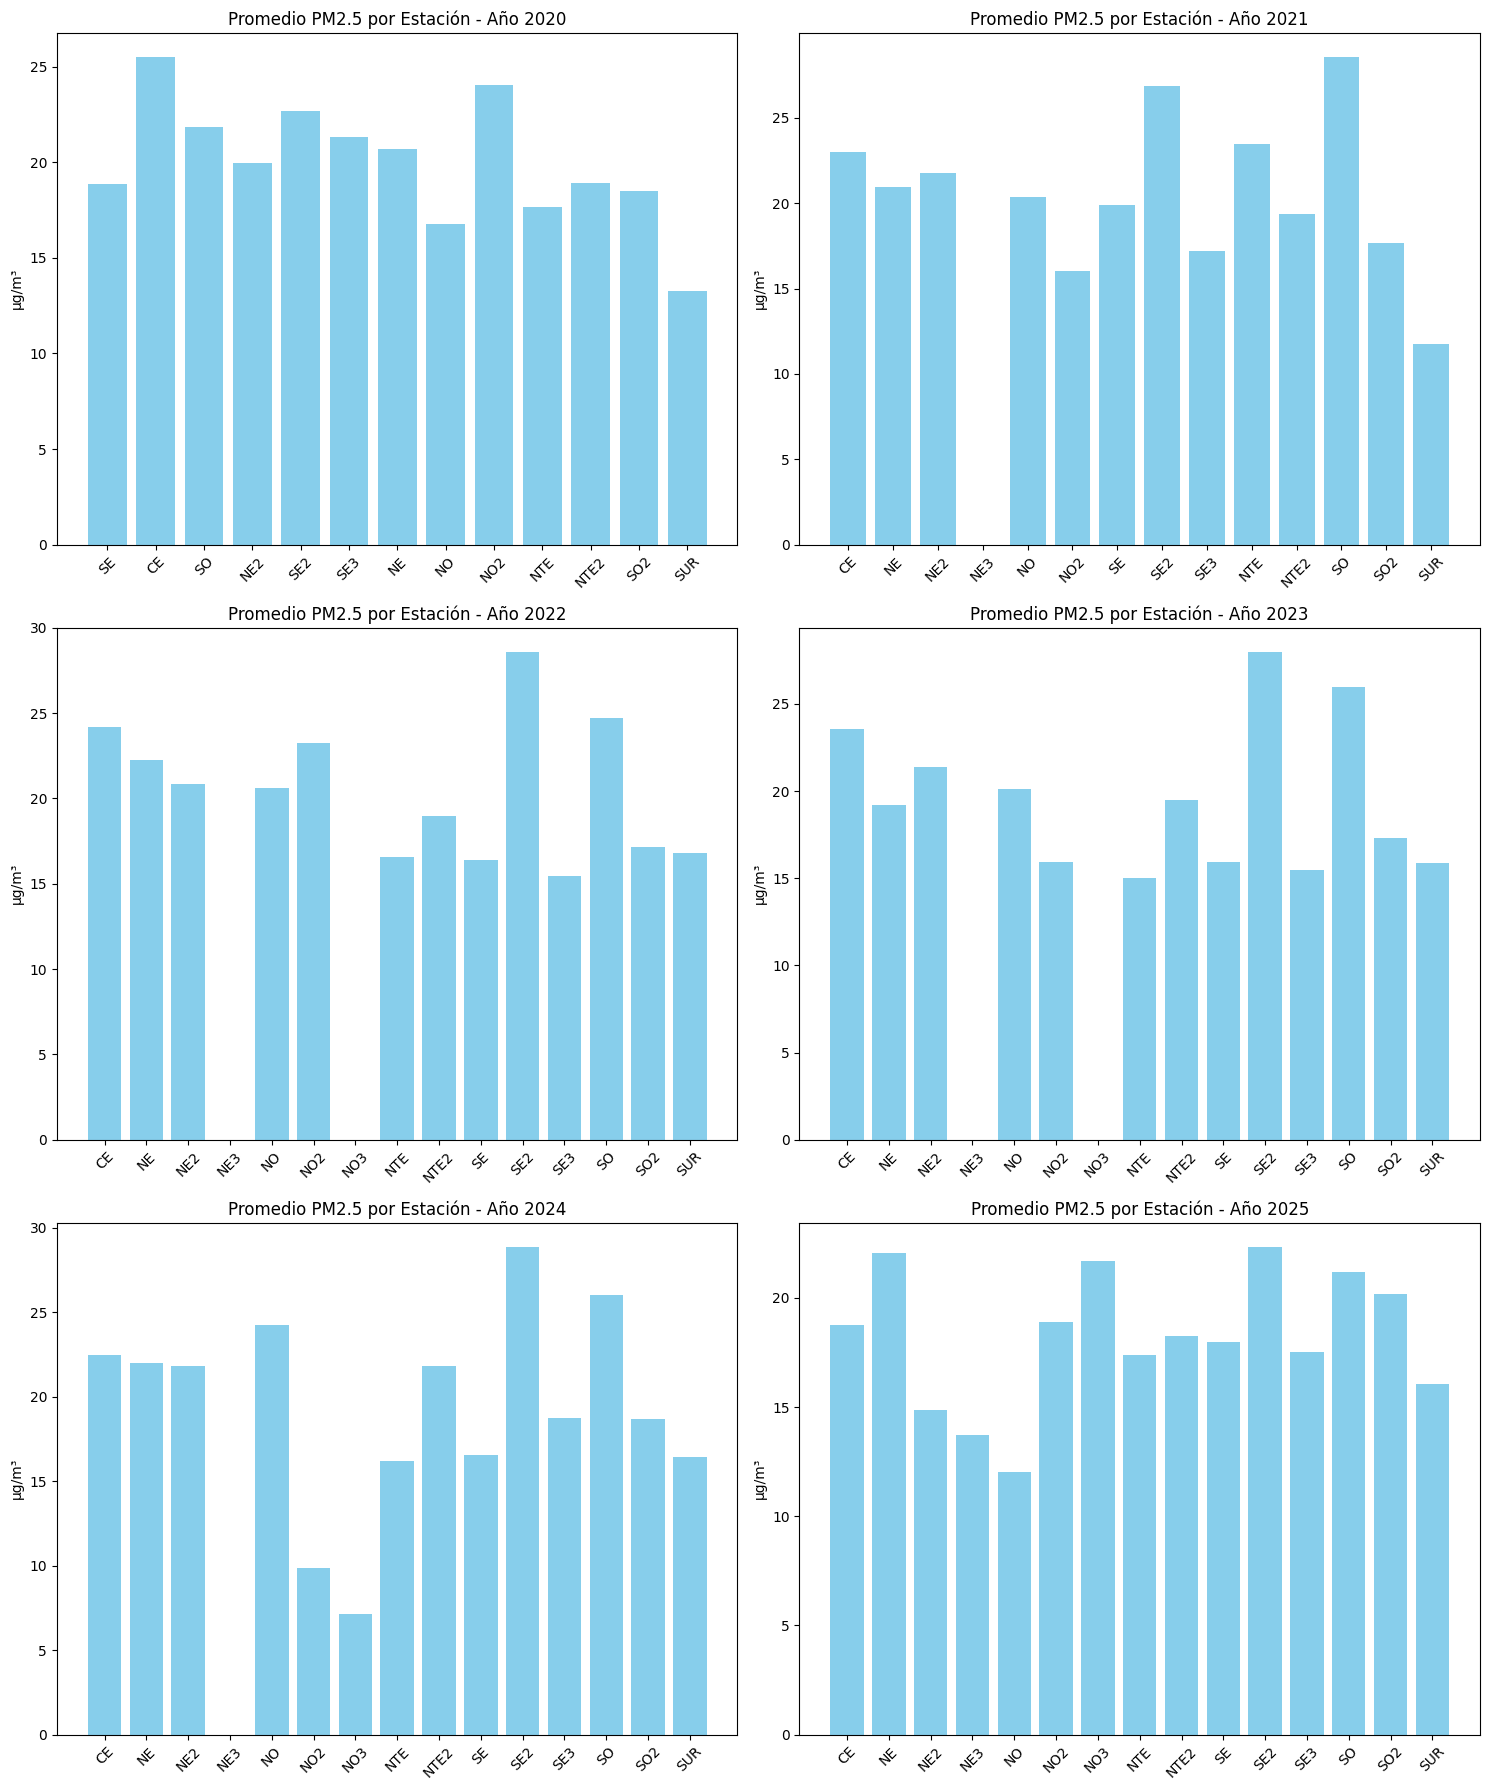

In [ ]:
# PM 2.5

import matplotlib.pyplot as plt

# Años a graficar
years = [2020, 2021, 2022, 2023, 2024, 2025]

# Configuración de la figura
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
axes = axes.flatten()

for i, year in enumerate(years):
    if year in datos_sima:
        estaciones = list(datos_sima[year].keys())
        # Calcular promedios asegurando que la columna existe en el DF de cada estación
        promedios = [datos_sima[year][est]['PM2.5'].mean() for est in estaciones if 'PM2.5' in datos_sima[year][est].columns]
        nombres_estaciones = [est for est in estaciones if 'PM2.5' in datos_sima[year][est].columns]

        axes[i].bar(nombres_estaciones, promedios, color='skyblue')
        axes[i].set_title(f'Promedio PM2.5 por Estación - Año {year}')
        axes[i].set_ylabel('µg/m³')
        axes[i].tick_params(axis='x', rotation=45)
    else:
        axes[i].set_title(f'Datos {year} no disponibles')

plt.tight_layout()
plt.show()

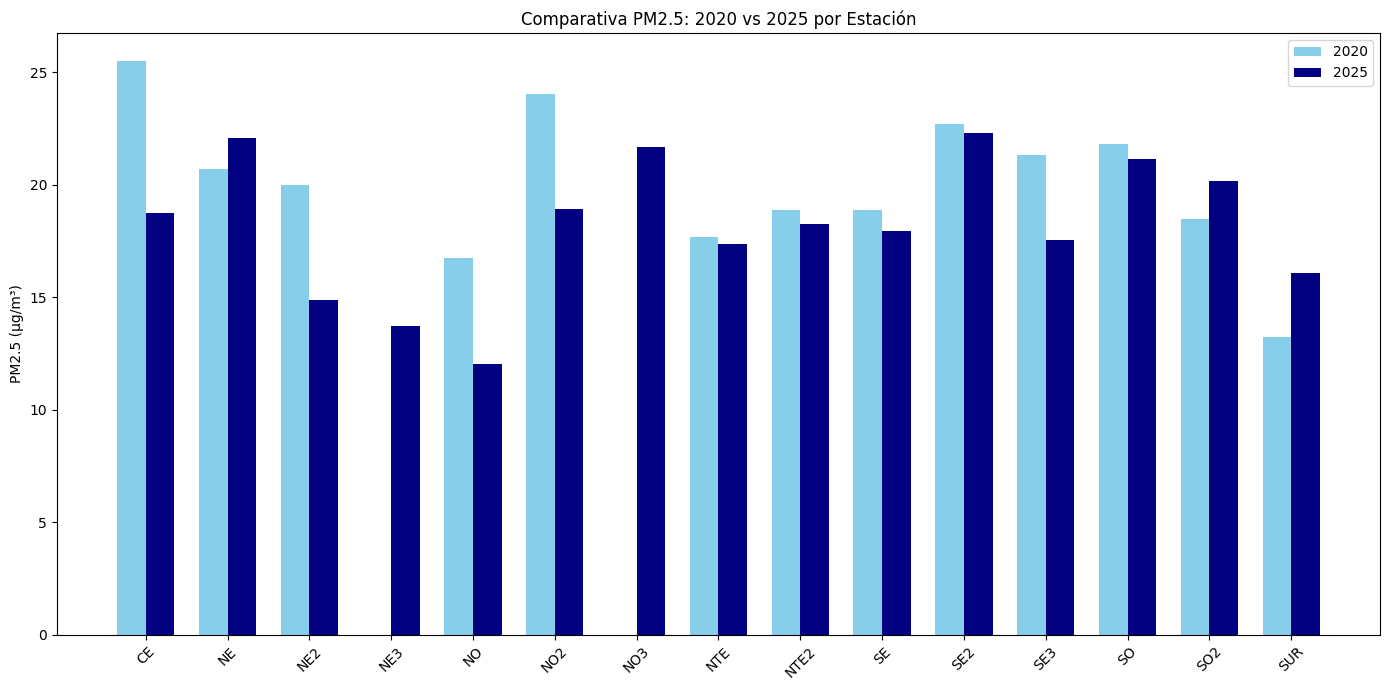

In [ ]:
import numpy as np

year_start = 2020
year_end = 2025

# Obtener lista única de estaciones que tienen datos de PM2.5 en alguno de los dos años
estaciones_2020 = set(datos_sima[year_start].keys()) if year_start in datos_sima else set()
estaciones_2025 = set(datos_sima[year_end].keys()) if year_end in datos_sima else set()
todas_estaciones = sorted(list(estaciones_2020.union(estaciones_2025)))

proms_2020 = []
proms_2025 = []
labels = []

for est in todas_estaciones:
    val_2020 = np.nan
    val_2025 = np.nan

    if year_start in datos_sima and est in datos_sima[year_start]:
        if 'PM2.5' in datos_sima[year_start][est].columns:
            val_2020 = datos_sima[year_start][est]['PM2.5'].mean()

    if year_end in datos_sima and est in datos_sima[year_end]:
        if 'PM2.5' in datos_sima[year_end][est].columns:
            val_2025 = datos_sima[year_end][est]['PM2.5'].mean()

    # Solo graficar si tenemos al menos un valor
    if not (np.isnan(val_2020) and np.isnan(val_2025)):
        labels.append(est)
        proms_2020.append(val_2020)
        proms_2025.append(val_2025)

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - width/2, proms_2020, width, label='2020', color='skyblue')
rects2 = ax.bar(x + width/2, proms_2025, width, label='2025', color='navy')

ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Comparativa PM2.5: 2020 vs 2025 por Estación')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

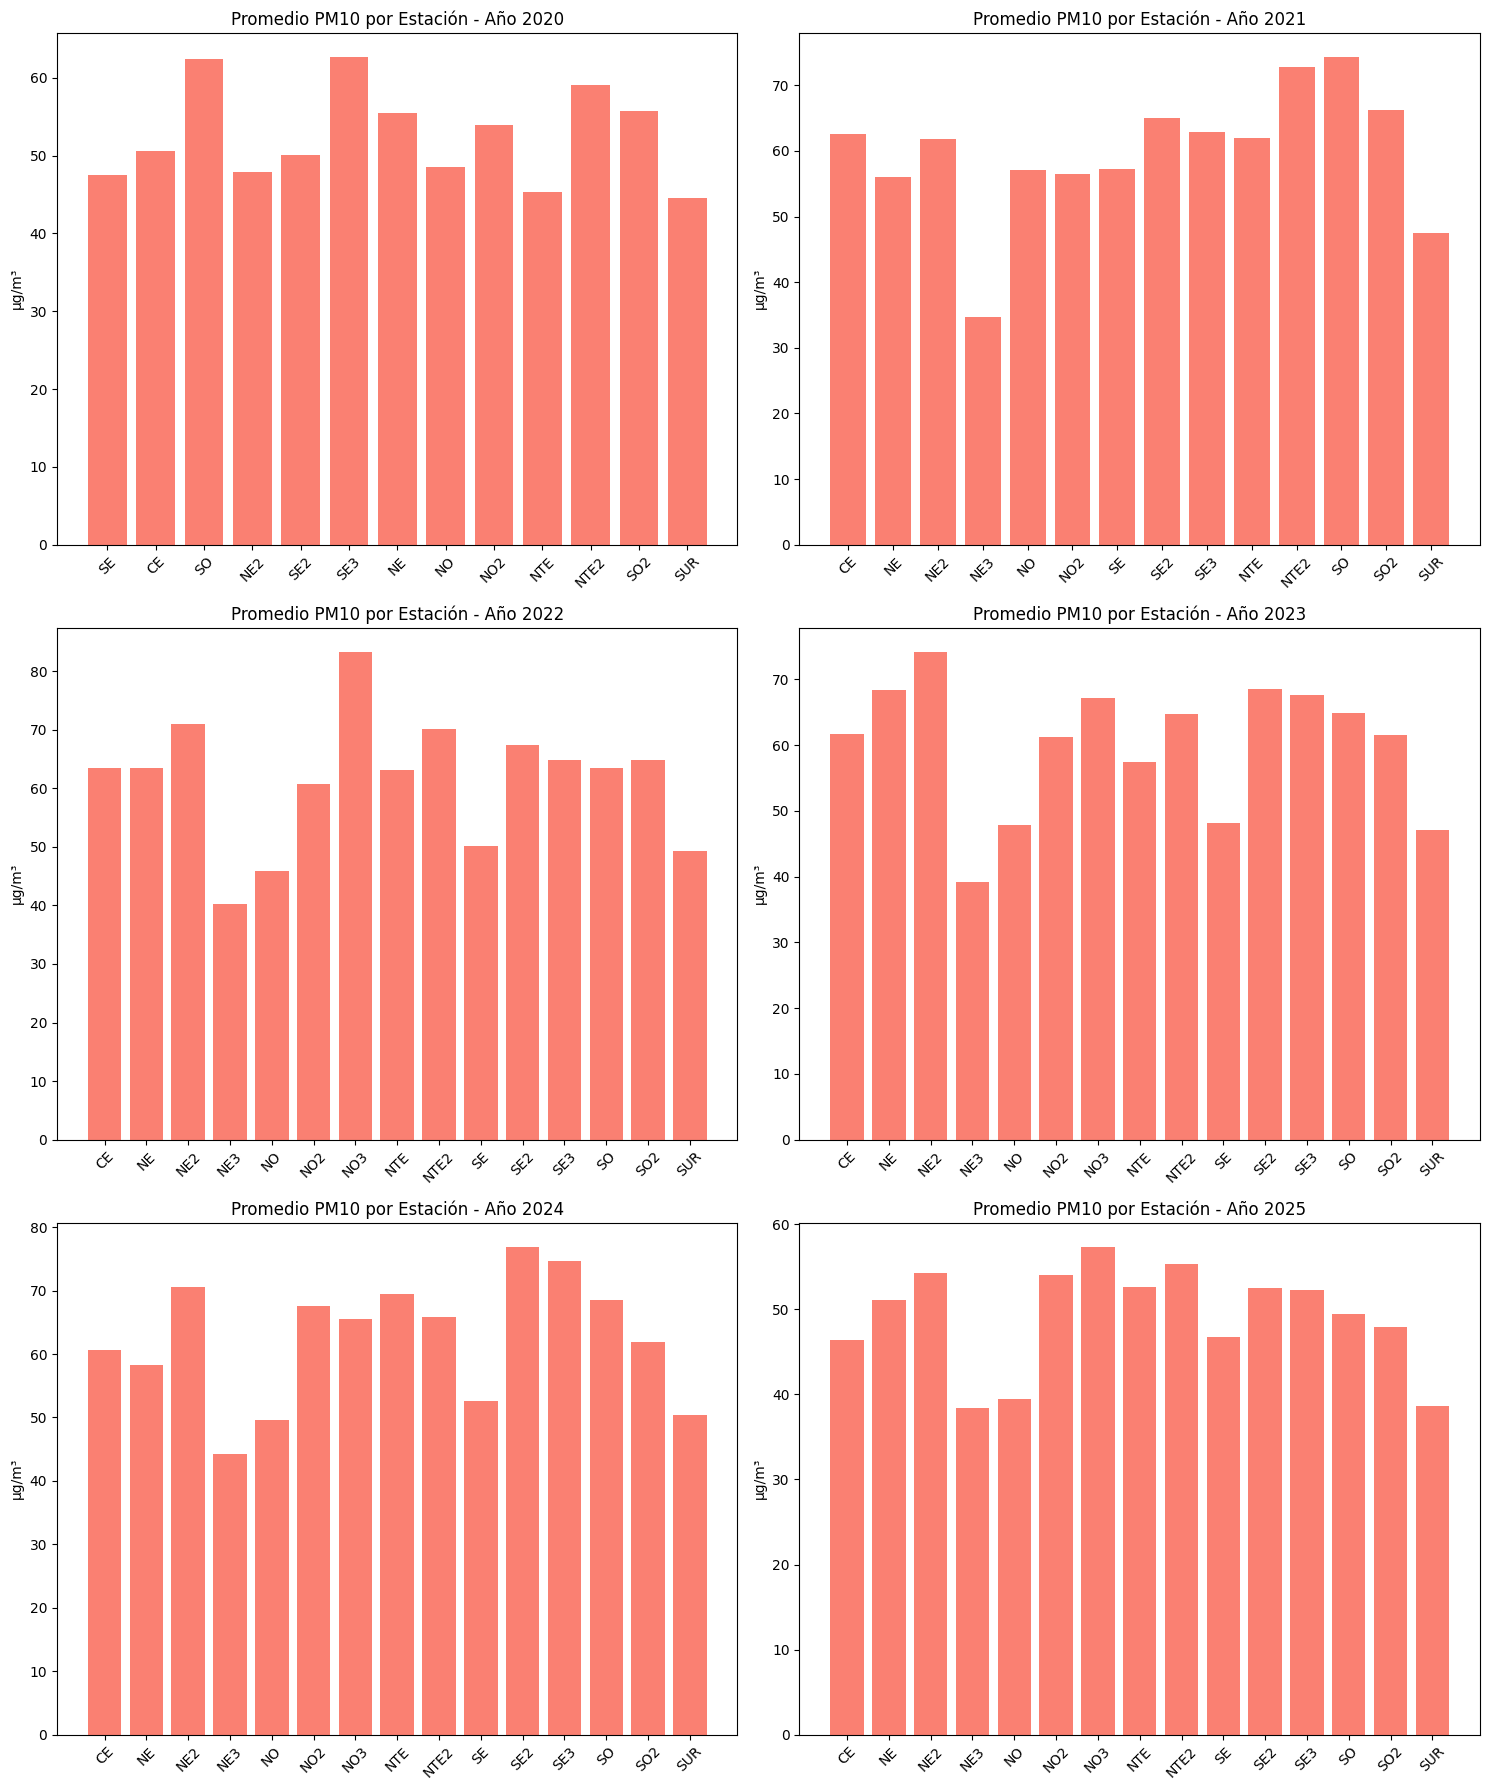

In [ ]:
# PM10

# Años a graficar
years = [2020, 2021, 2022, 2023, 2024, 2025]

# Configuración de la figura
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
axes = axes.flatten()

for i, year in enumerate(years):
    if year in datos_sima:
        estaciones = list(datos_sima[year].keys())
        # Calcular promedios asegurando que la columna existe en el DF de cada estación
        promedios = [datos_sima[year][est]['PM10'].mean() for est in estaciones if 'PM10' in datos_sima[year][est].columns]
        nombres_estaciones = [est for est in estaciones if 'PM10' in datos_sima[year][est].columns]

        axes[i].bar(nombres_estaciones, promedios, color='salmon')
        axes[i].set_title(f'Promedio PM10 por Estación - Año {year}')
        axes[i].set_ylabel('µg/m³')
        axes[i].tick_params(axis='x', rotation=45)
    else:
        axes[i].set_title(f'Datos {year} no disponibles')

plt.tight_layout()
plt.show()

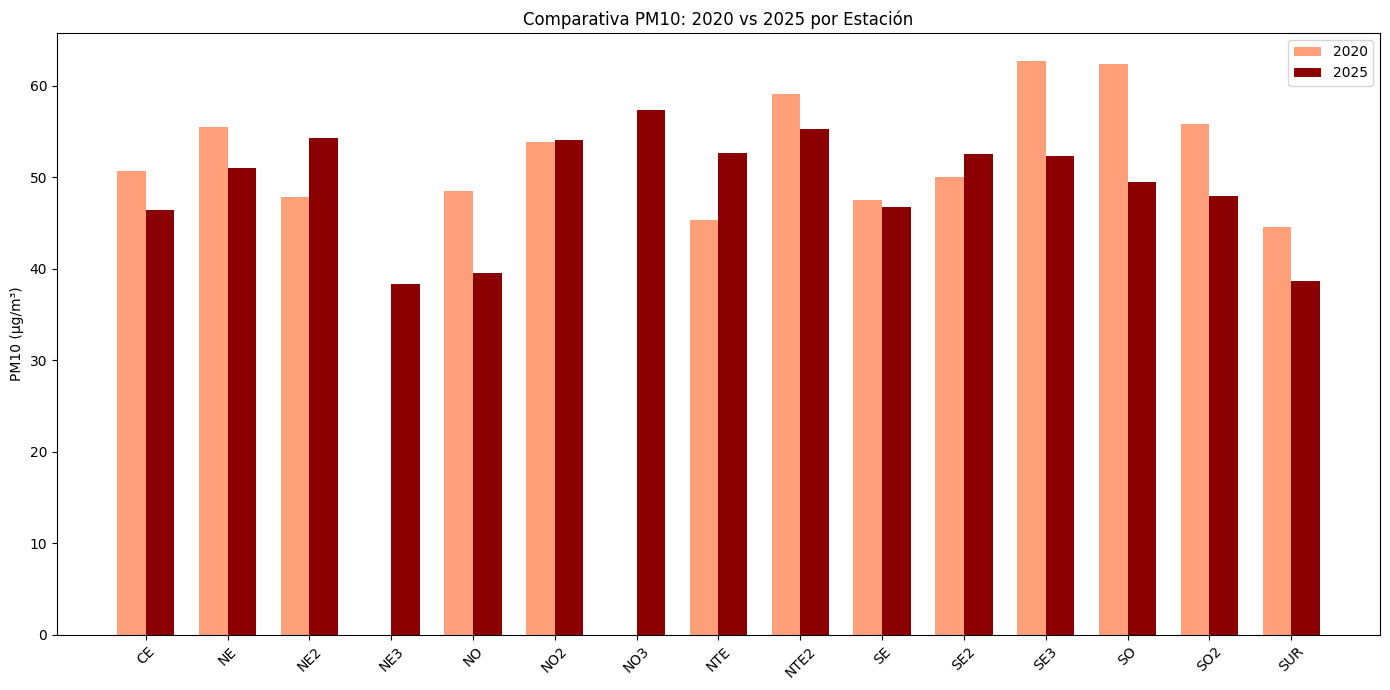

In [ ]:
year_start = 2020
year_end = 2025

# Obtener lista única de estaciones
estaciones_2020 = set(datos_sima[year_start].keys()) if year_start in datos_sima else set()
estaciones_2025 = set(datos_sima[year_end].keys()) if year_end in datos_sima else set()
todas_estaciones = sorted(list(estaciones_2020.union(estaciones_2025)))

proms_2020 = []
proms_2025 = []
labels = []

for est in todas_estaciones:
    val_2020 = np.nan
    val_2025 = np.nan

    if year_start in datos_sima and est in datos_sima[year_start]:
        if 'PM10' in datos_sima[year_start][est].columns:
            val_2020 = datos_sima[year_start][est]['PM10'].mean()

    if year_end in datos_sima and est in datos_sima[year_end]:
        if 'PM10' in datos_sima[year_end][est].columns:
            val_2025 = datos_sima[year_end][est]['PM10'].mean()

    if not (np.isnan(val_2020) and np.isnan(val_2025)):
        labels.append(est)
        proms_2020.append(val_2020)
        proms_2025.append(val_2025)

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - width/2, proms_2020, width, label='2020', color='lightsalmon')
rects2 = ax.bar(x + width/2, proms_2025, width, label='2025', color='darkred')

ax.set_ylabel('PM10 (µg/m³)')
ax.set_title('Comparativa PM10: 2020 vs 2025 por Estación')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

--- Generando visualizaciones para PM2.5 ---


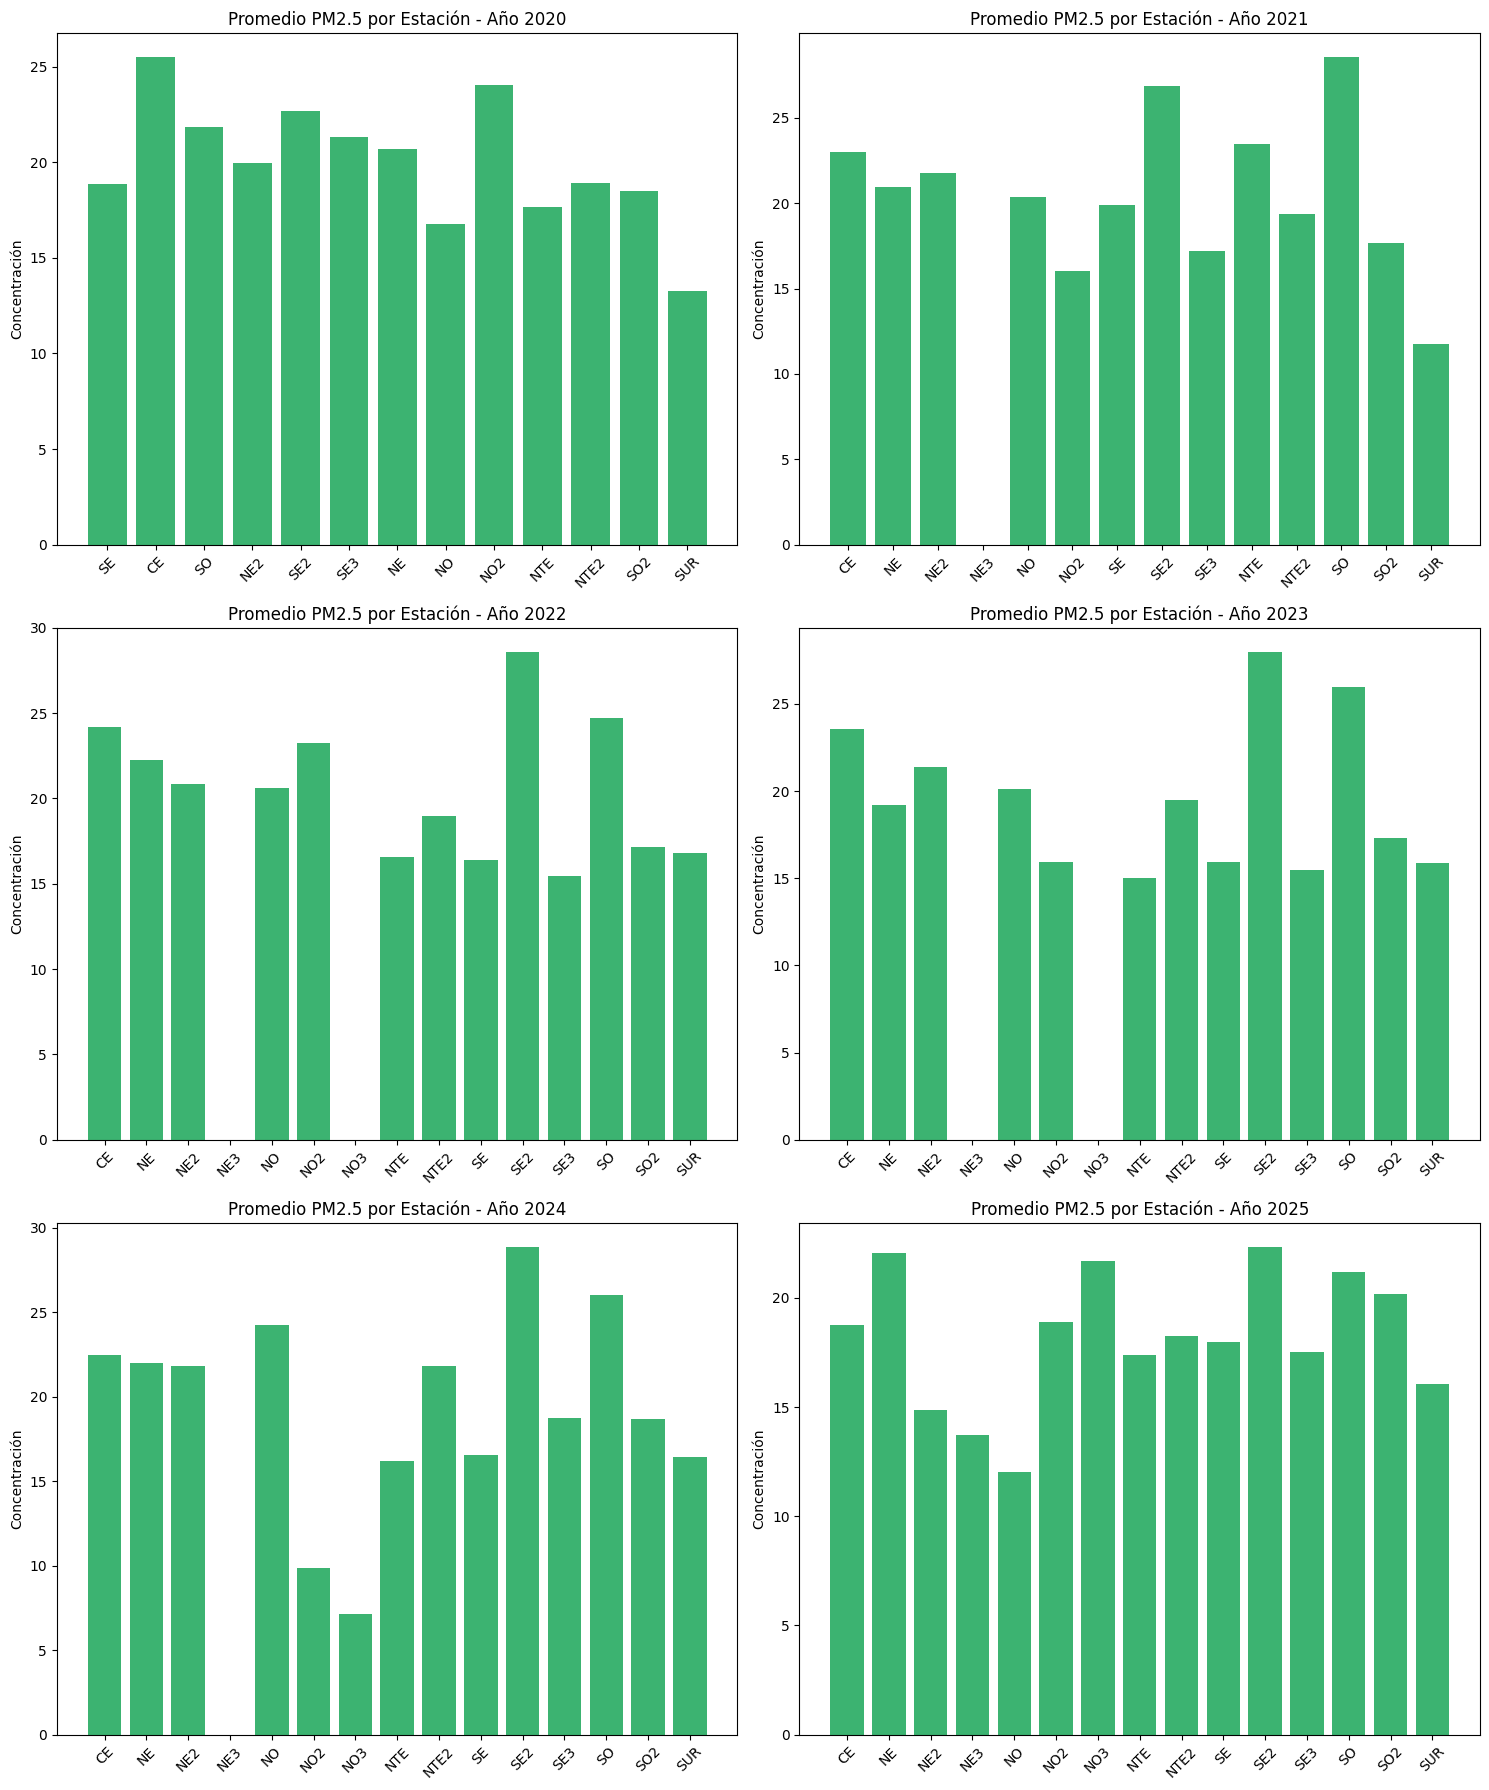

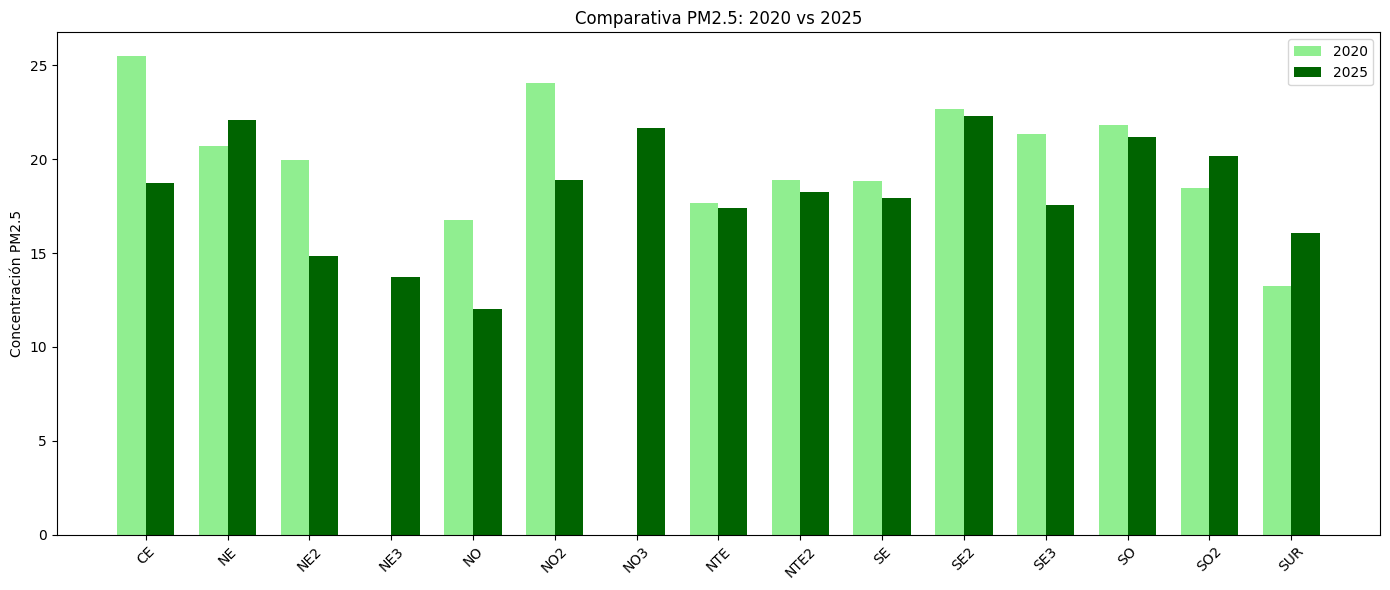

--- Generando visualizaciones para PM10 ---


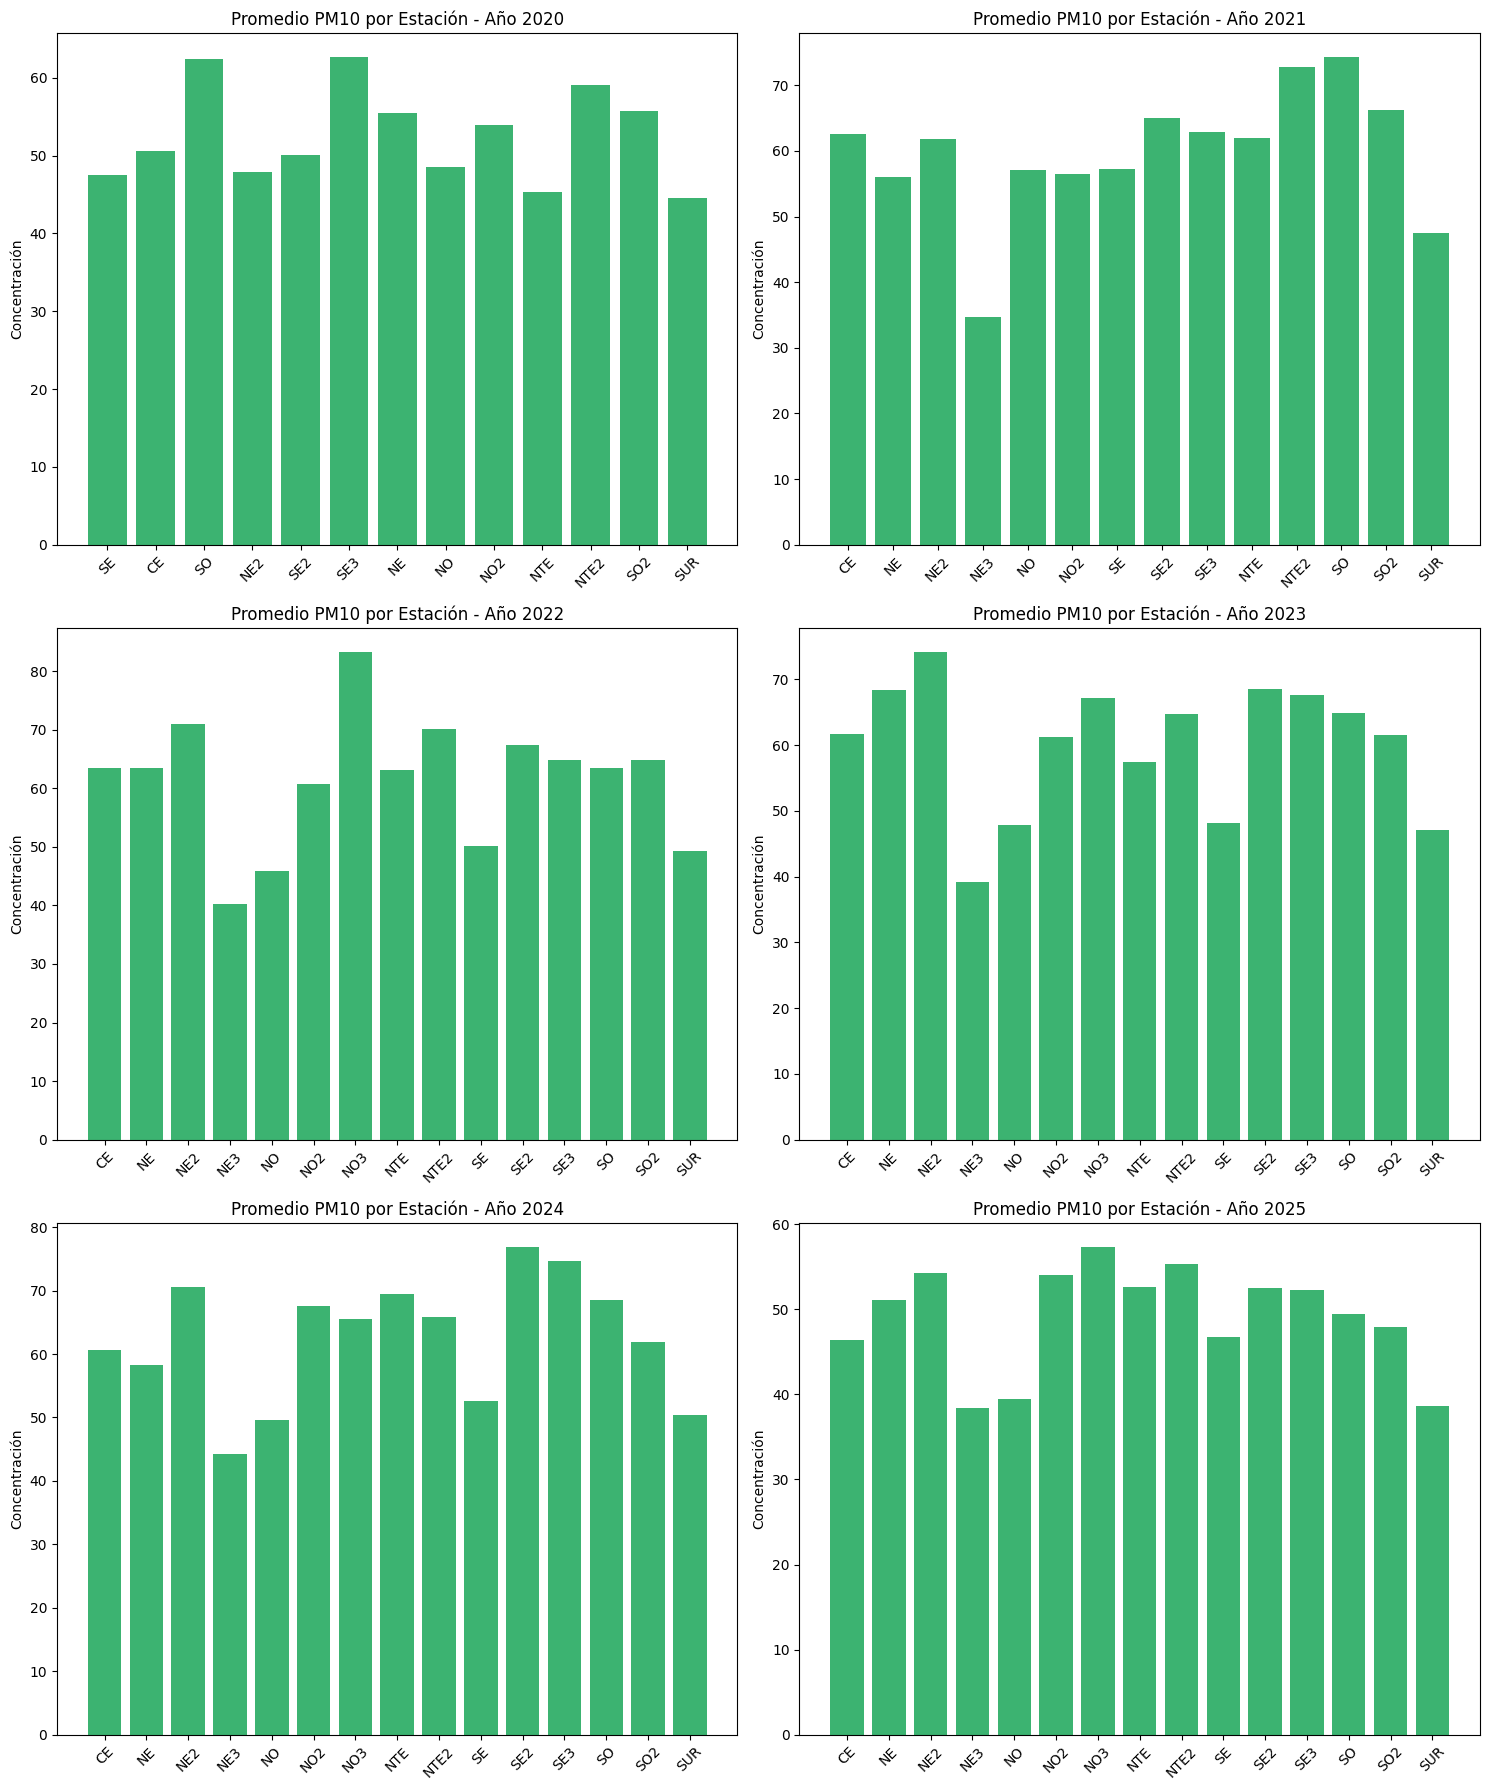

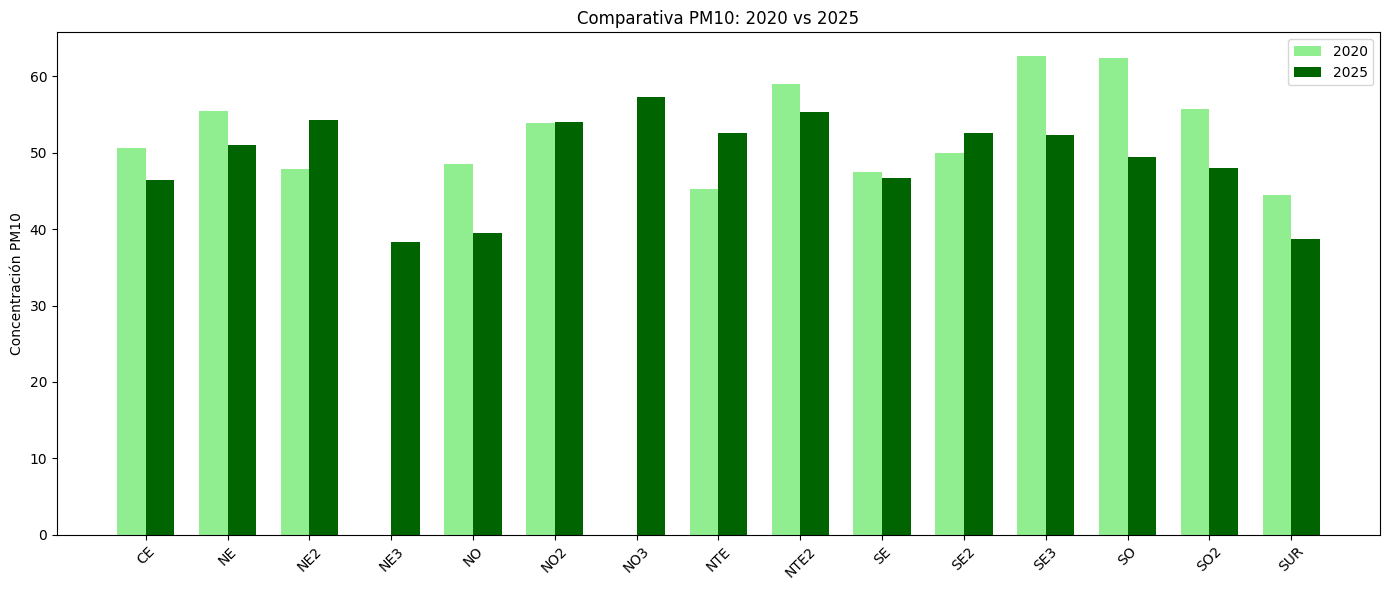

--- Generando visualizaciones para SO2 ---


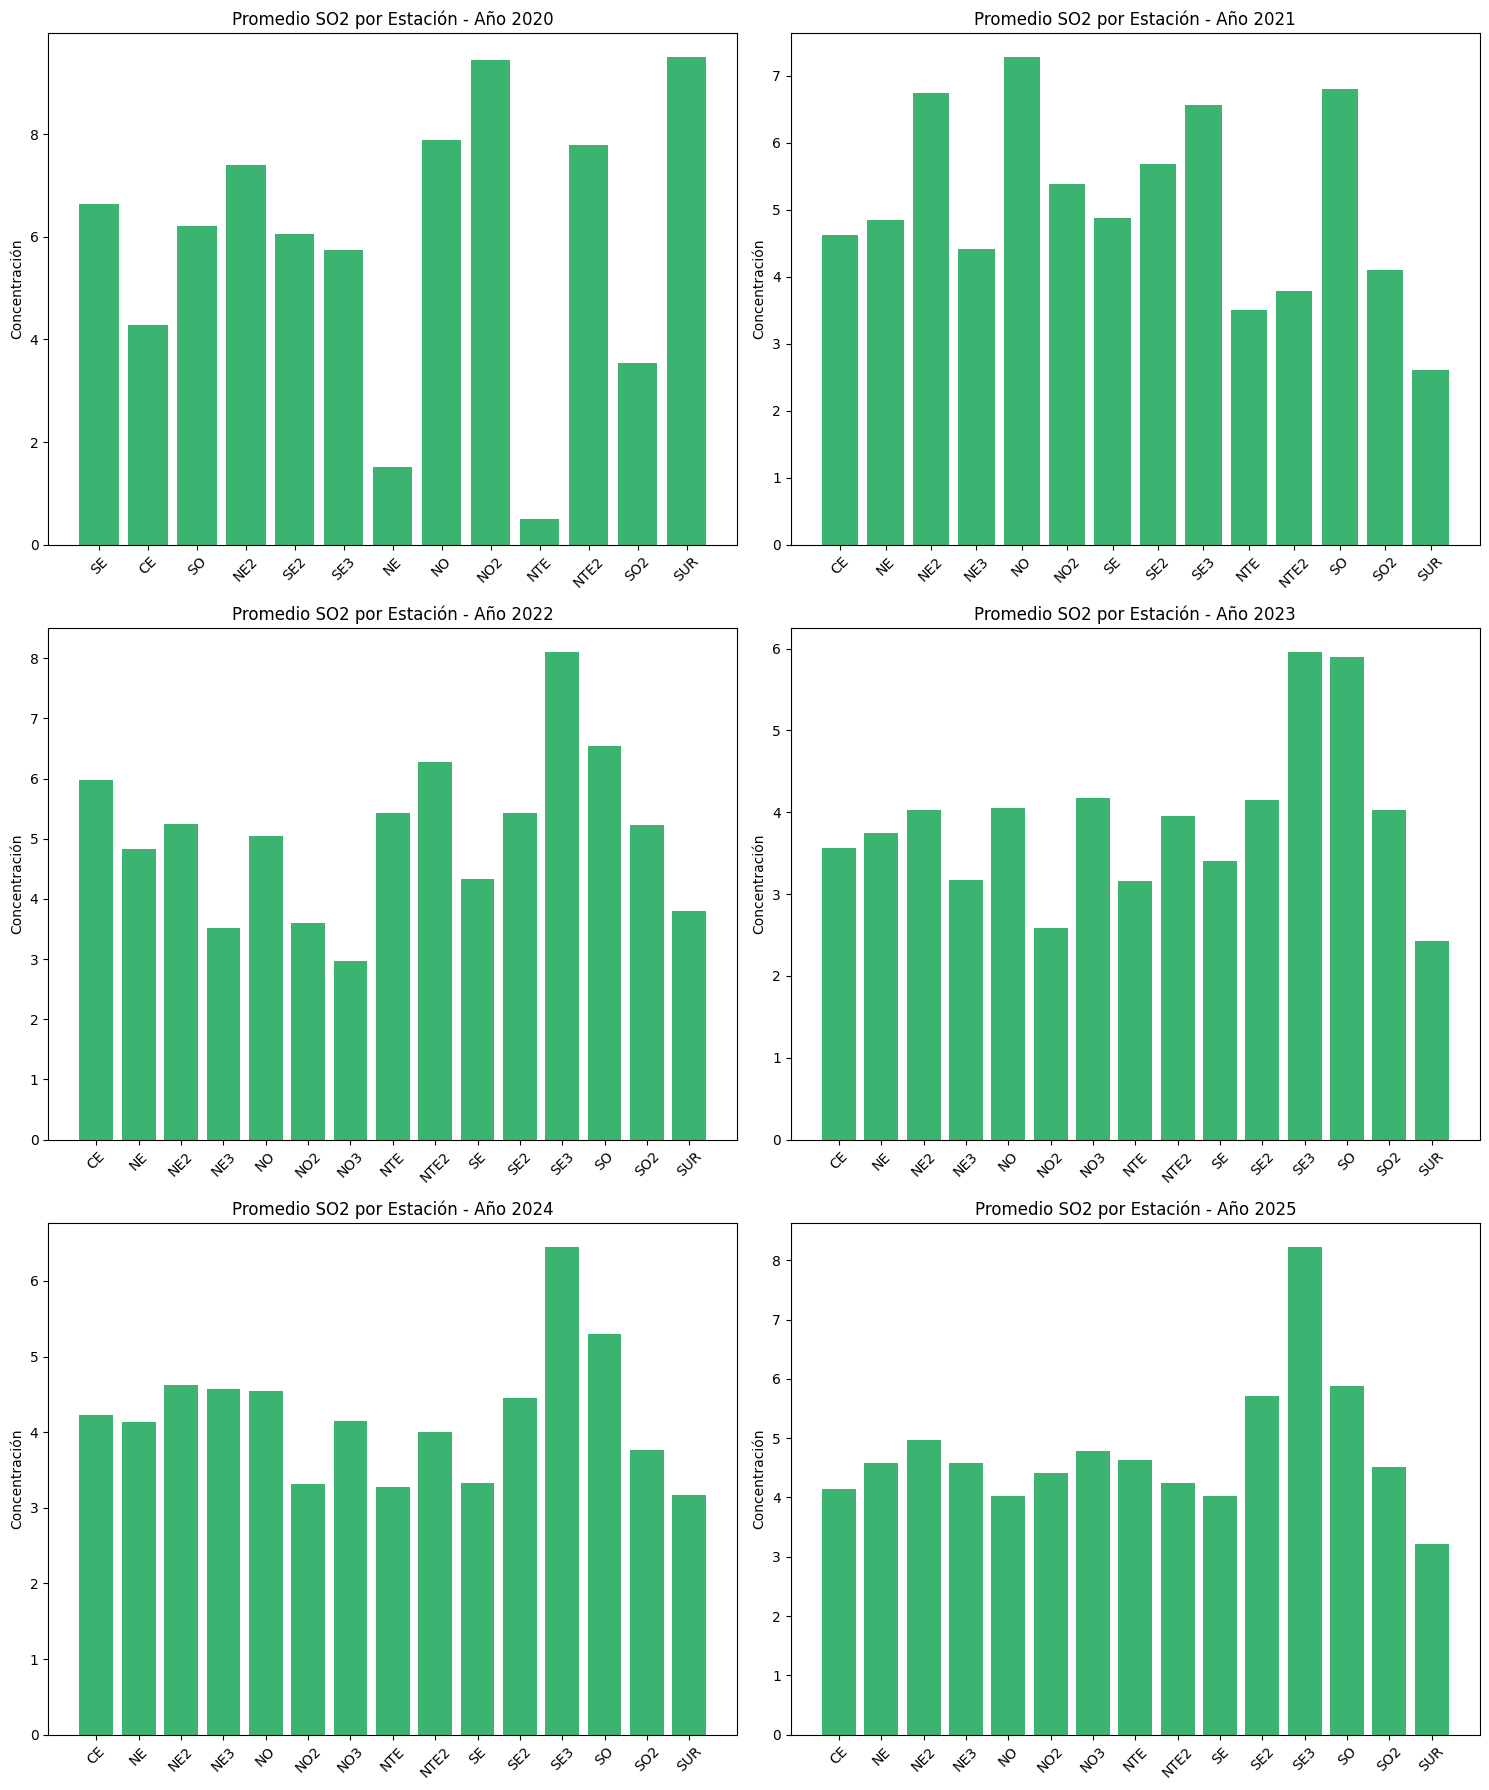

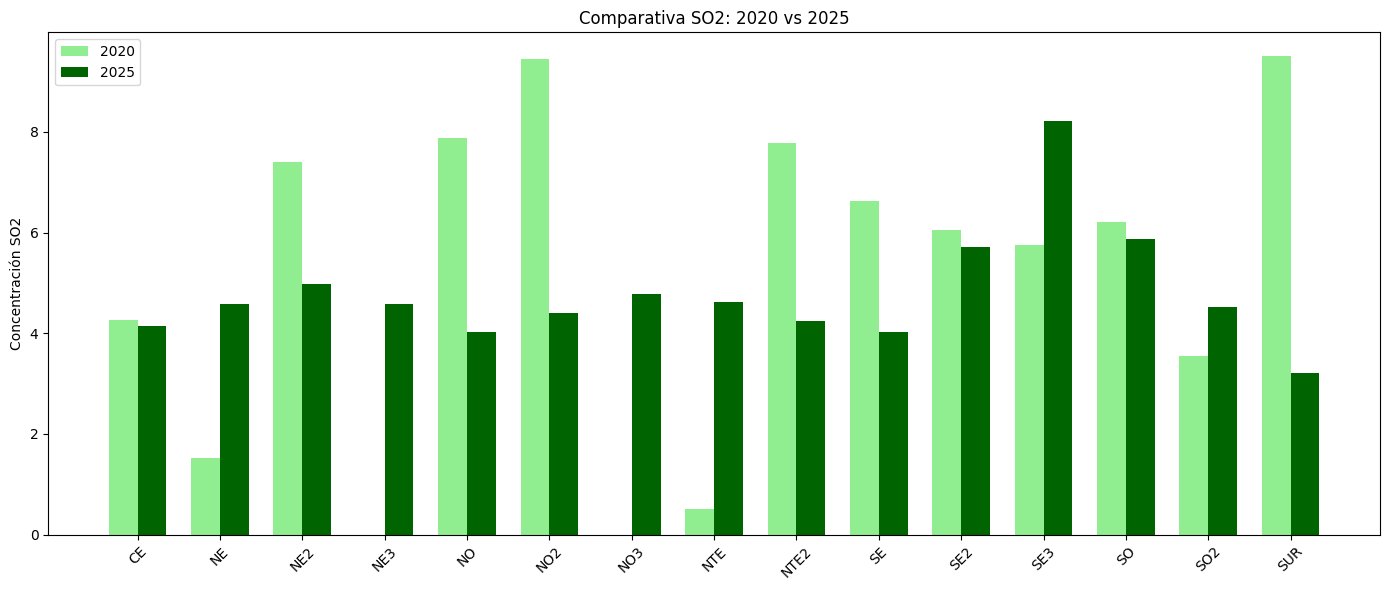

--- Generando visualizaciones para CO ---


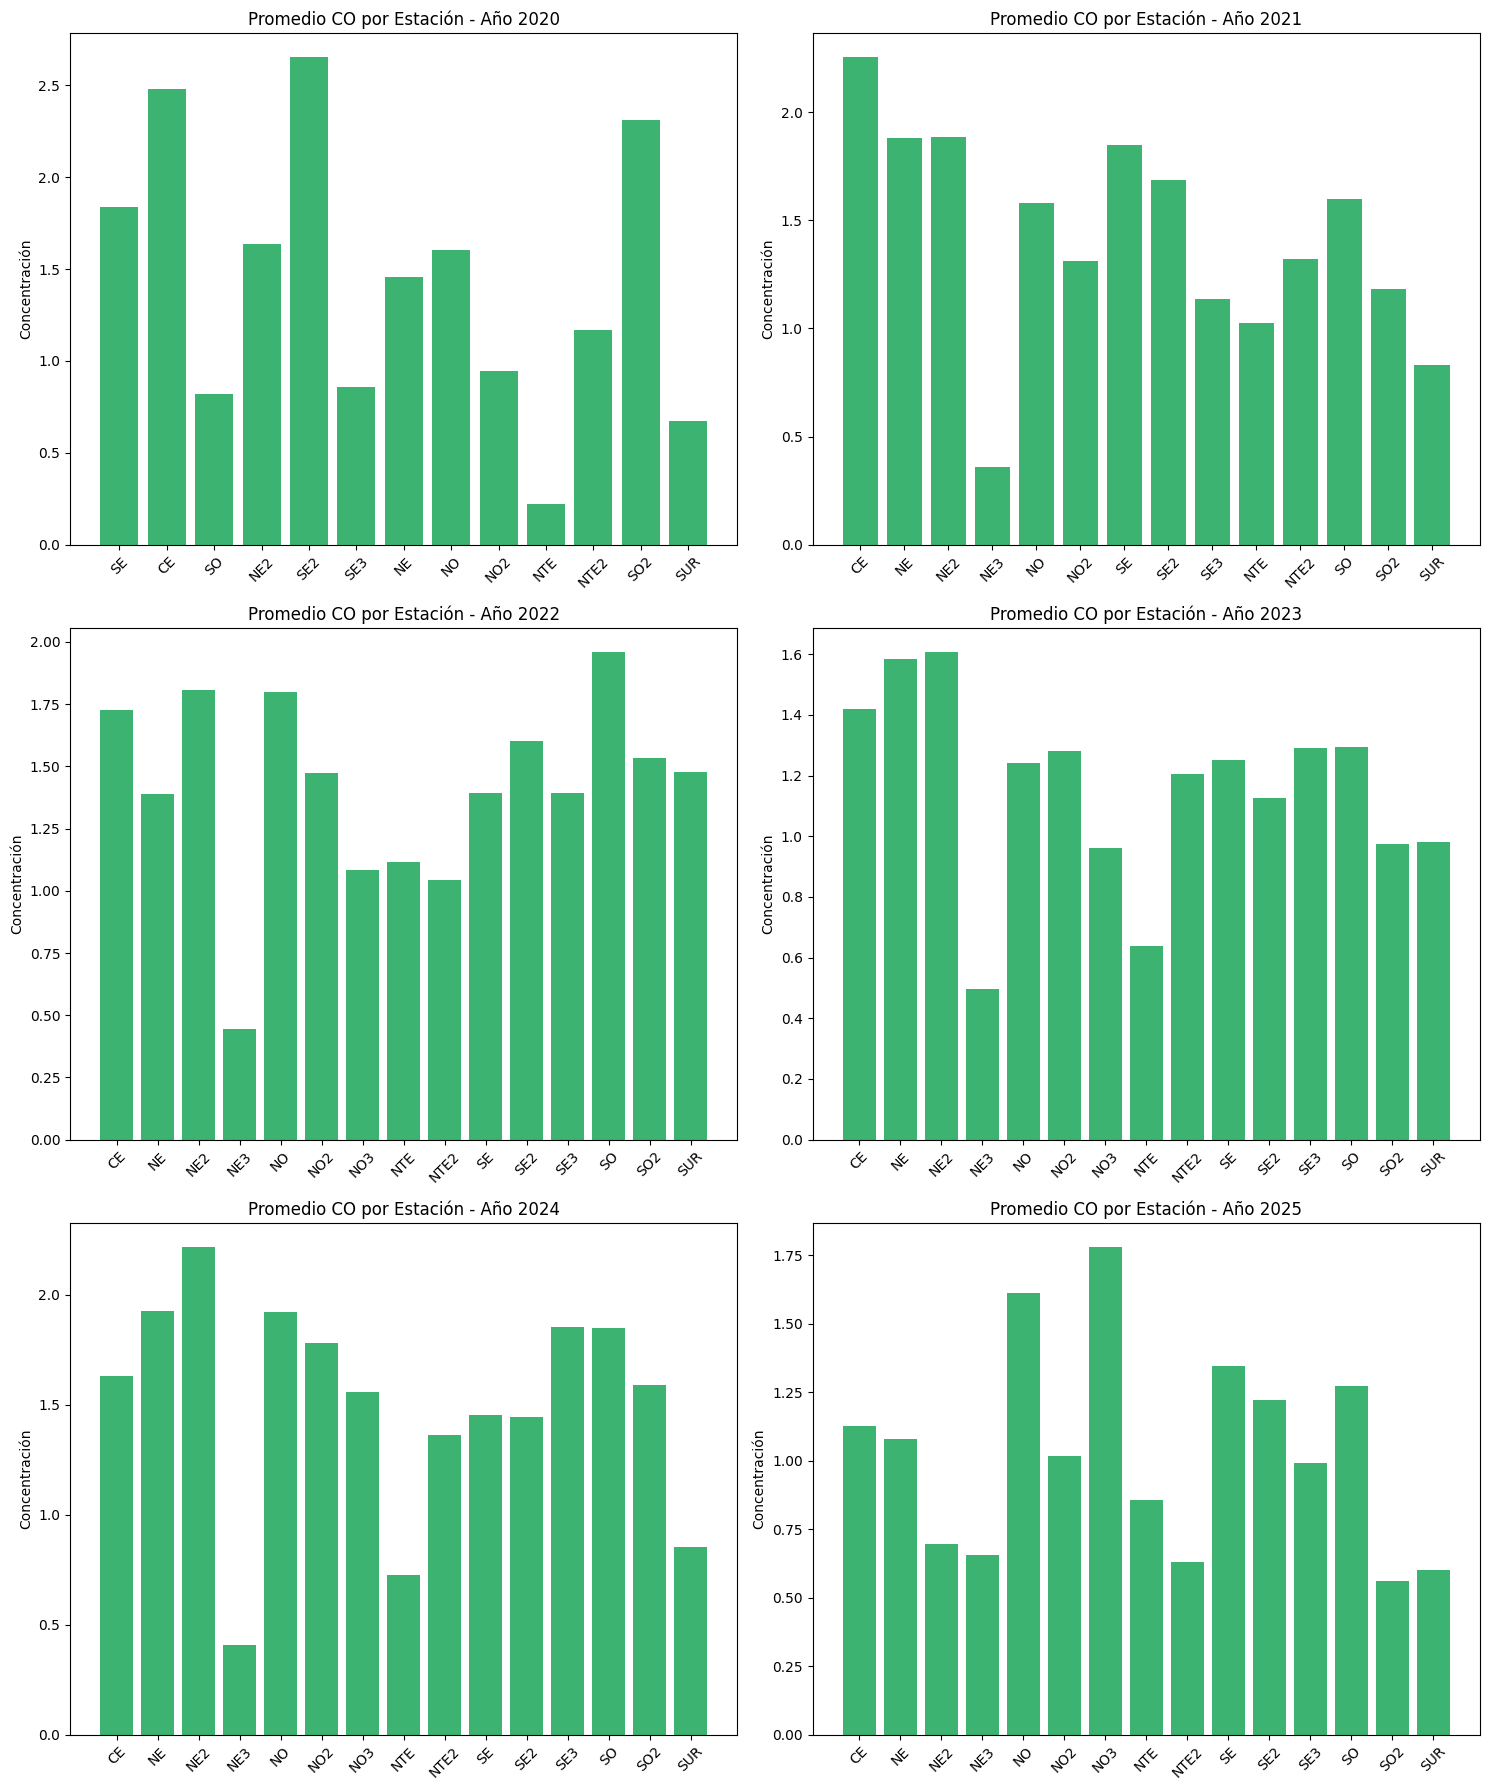

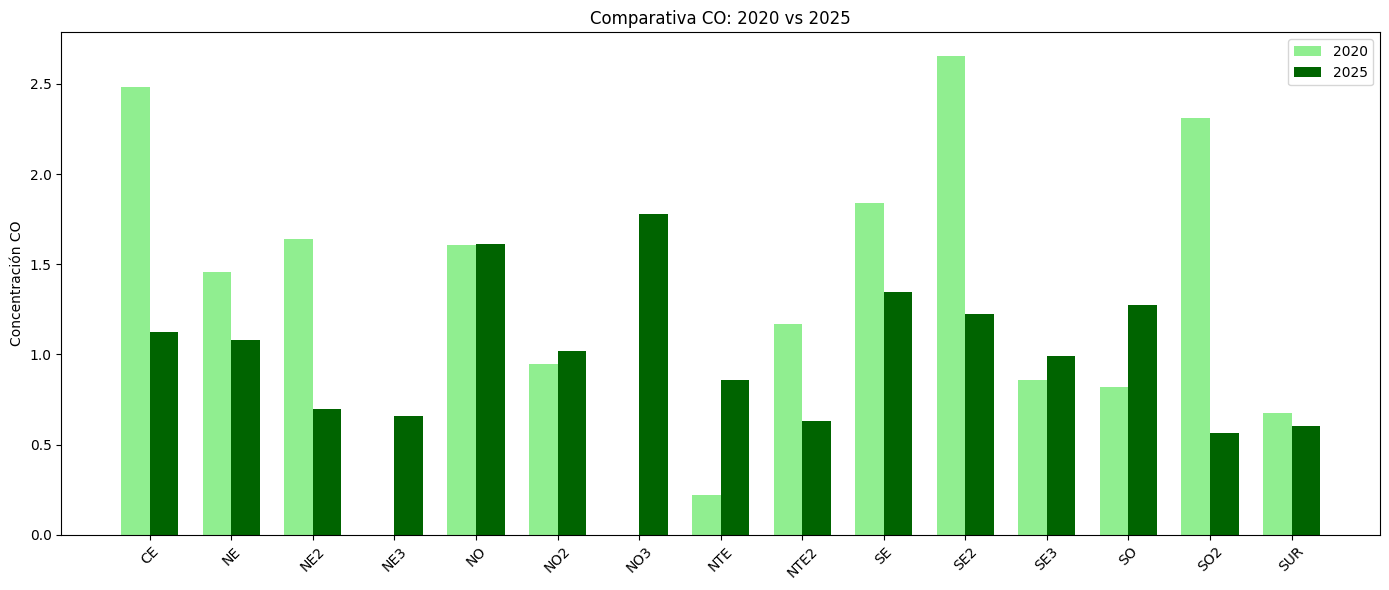

--- Generando visualizaciones para NO ---


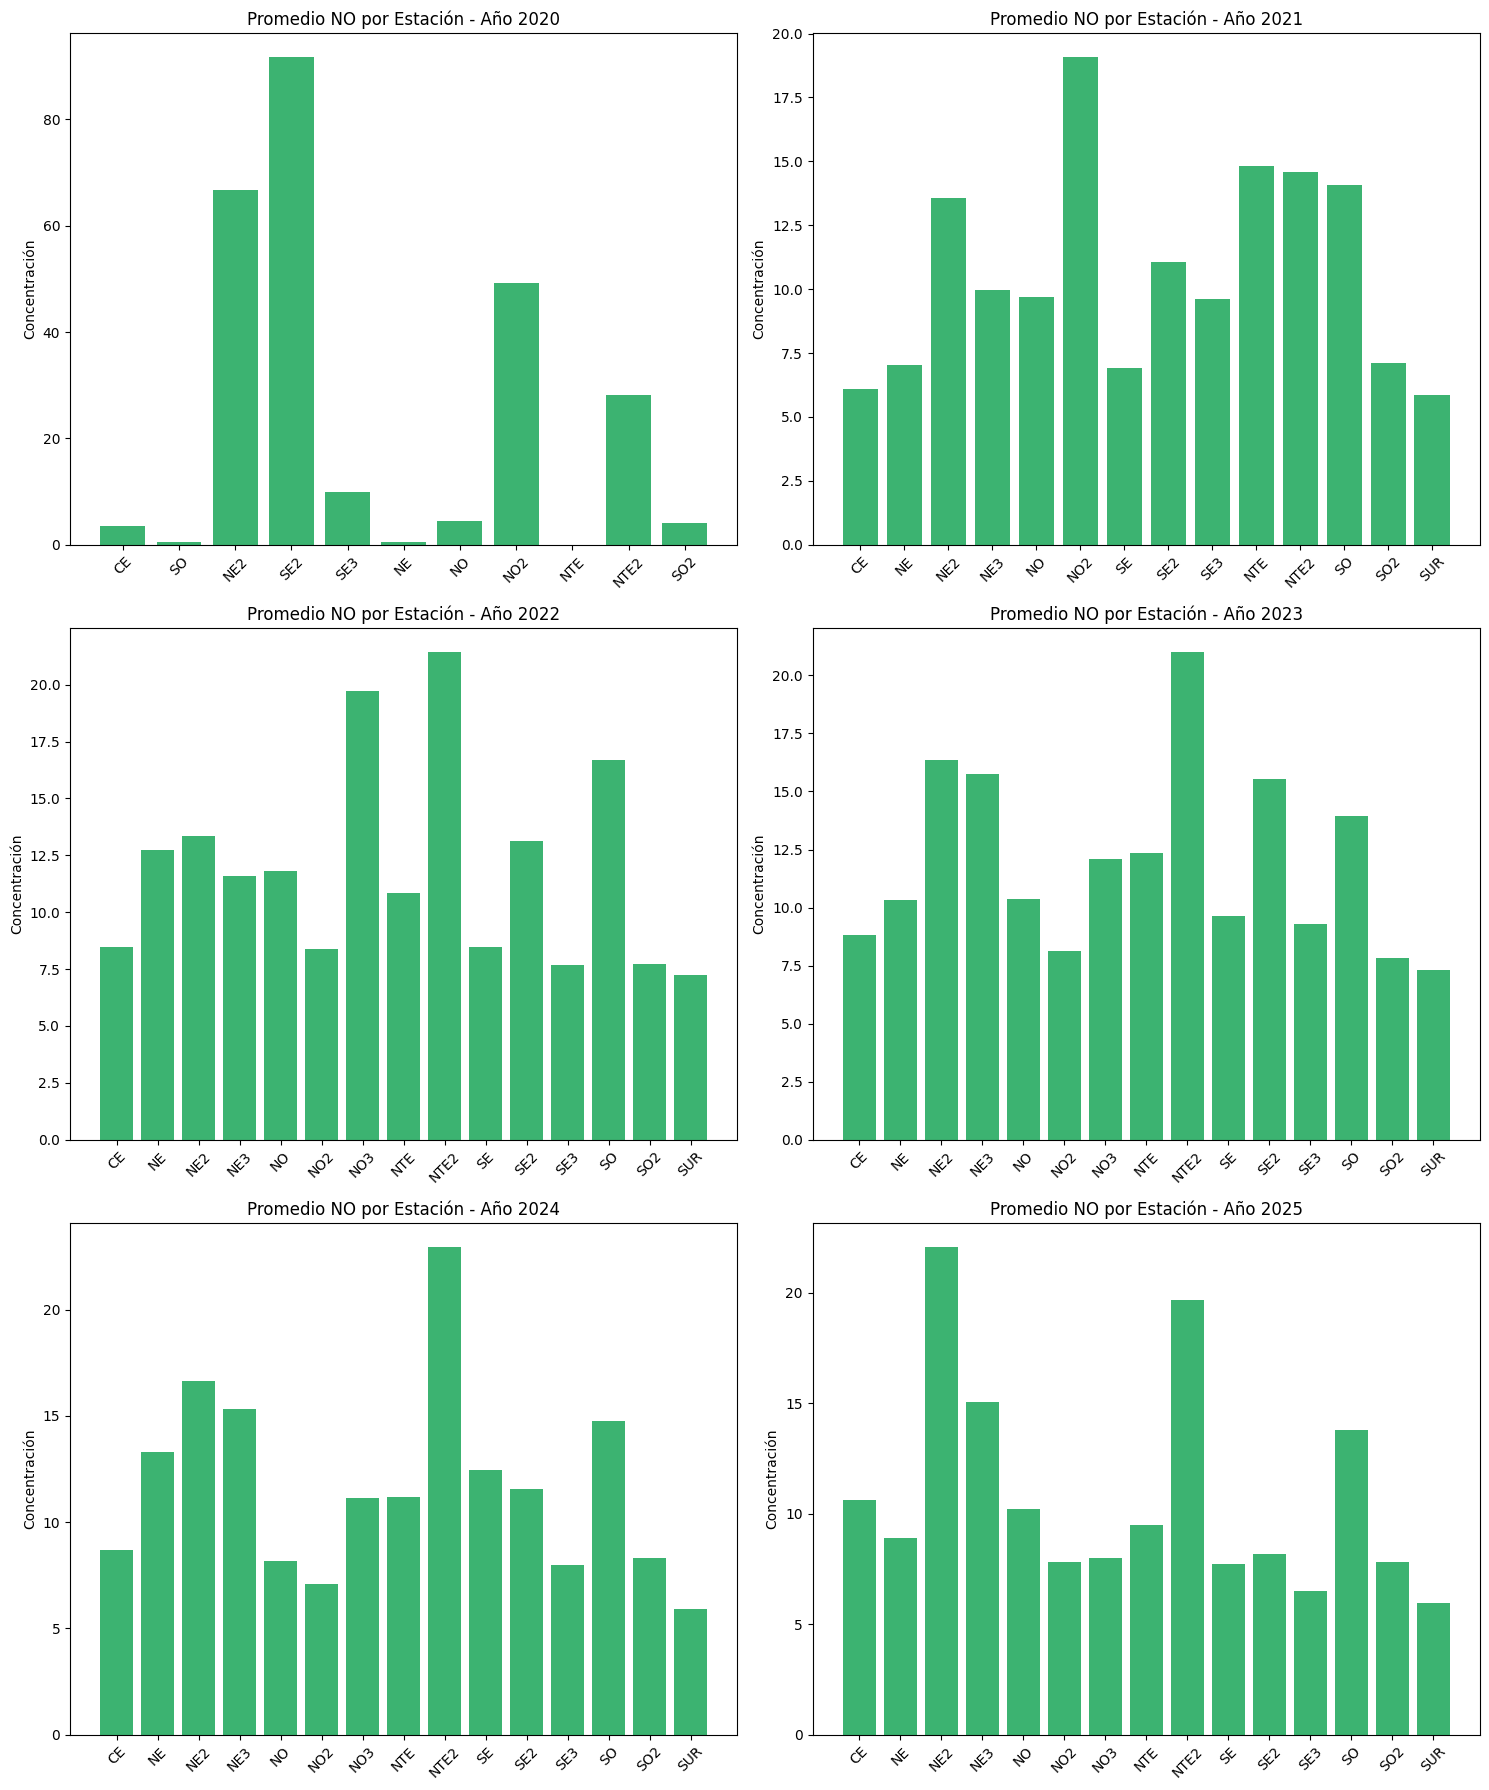

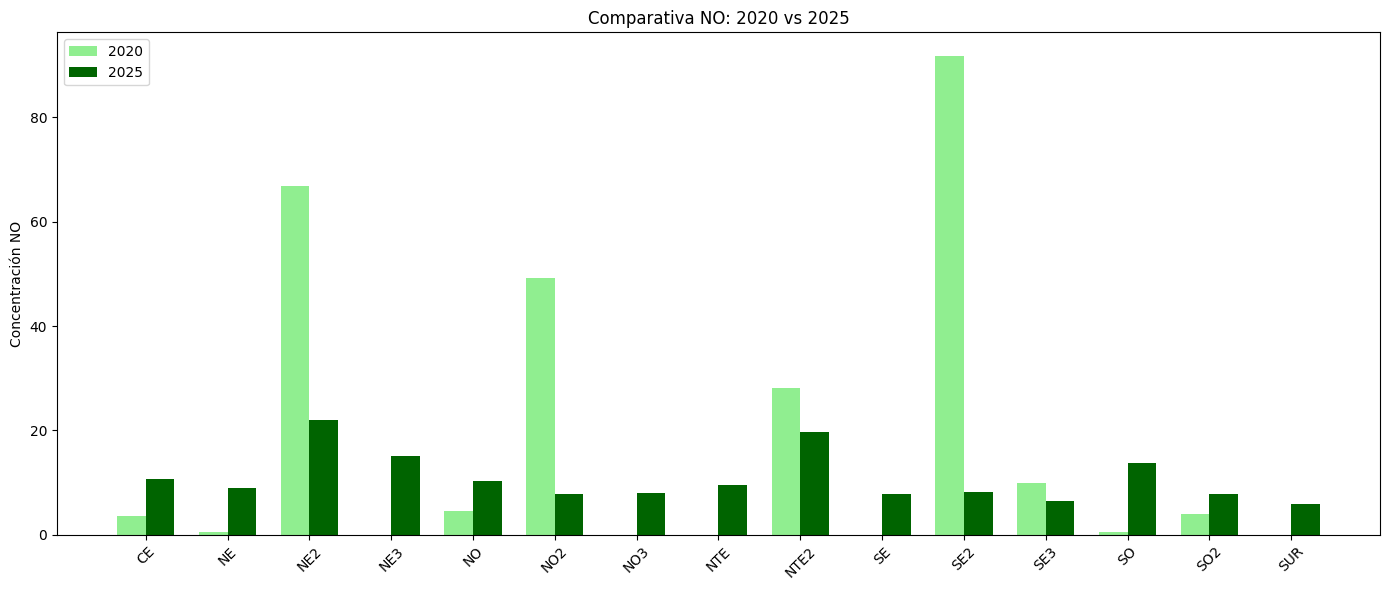

--- Generando visualizaciones para NO2 ---


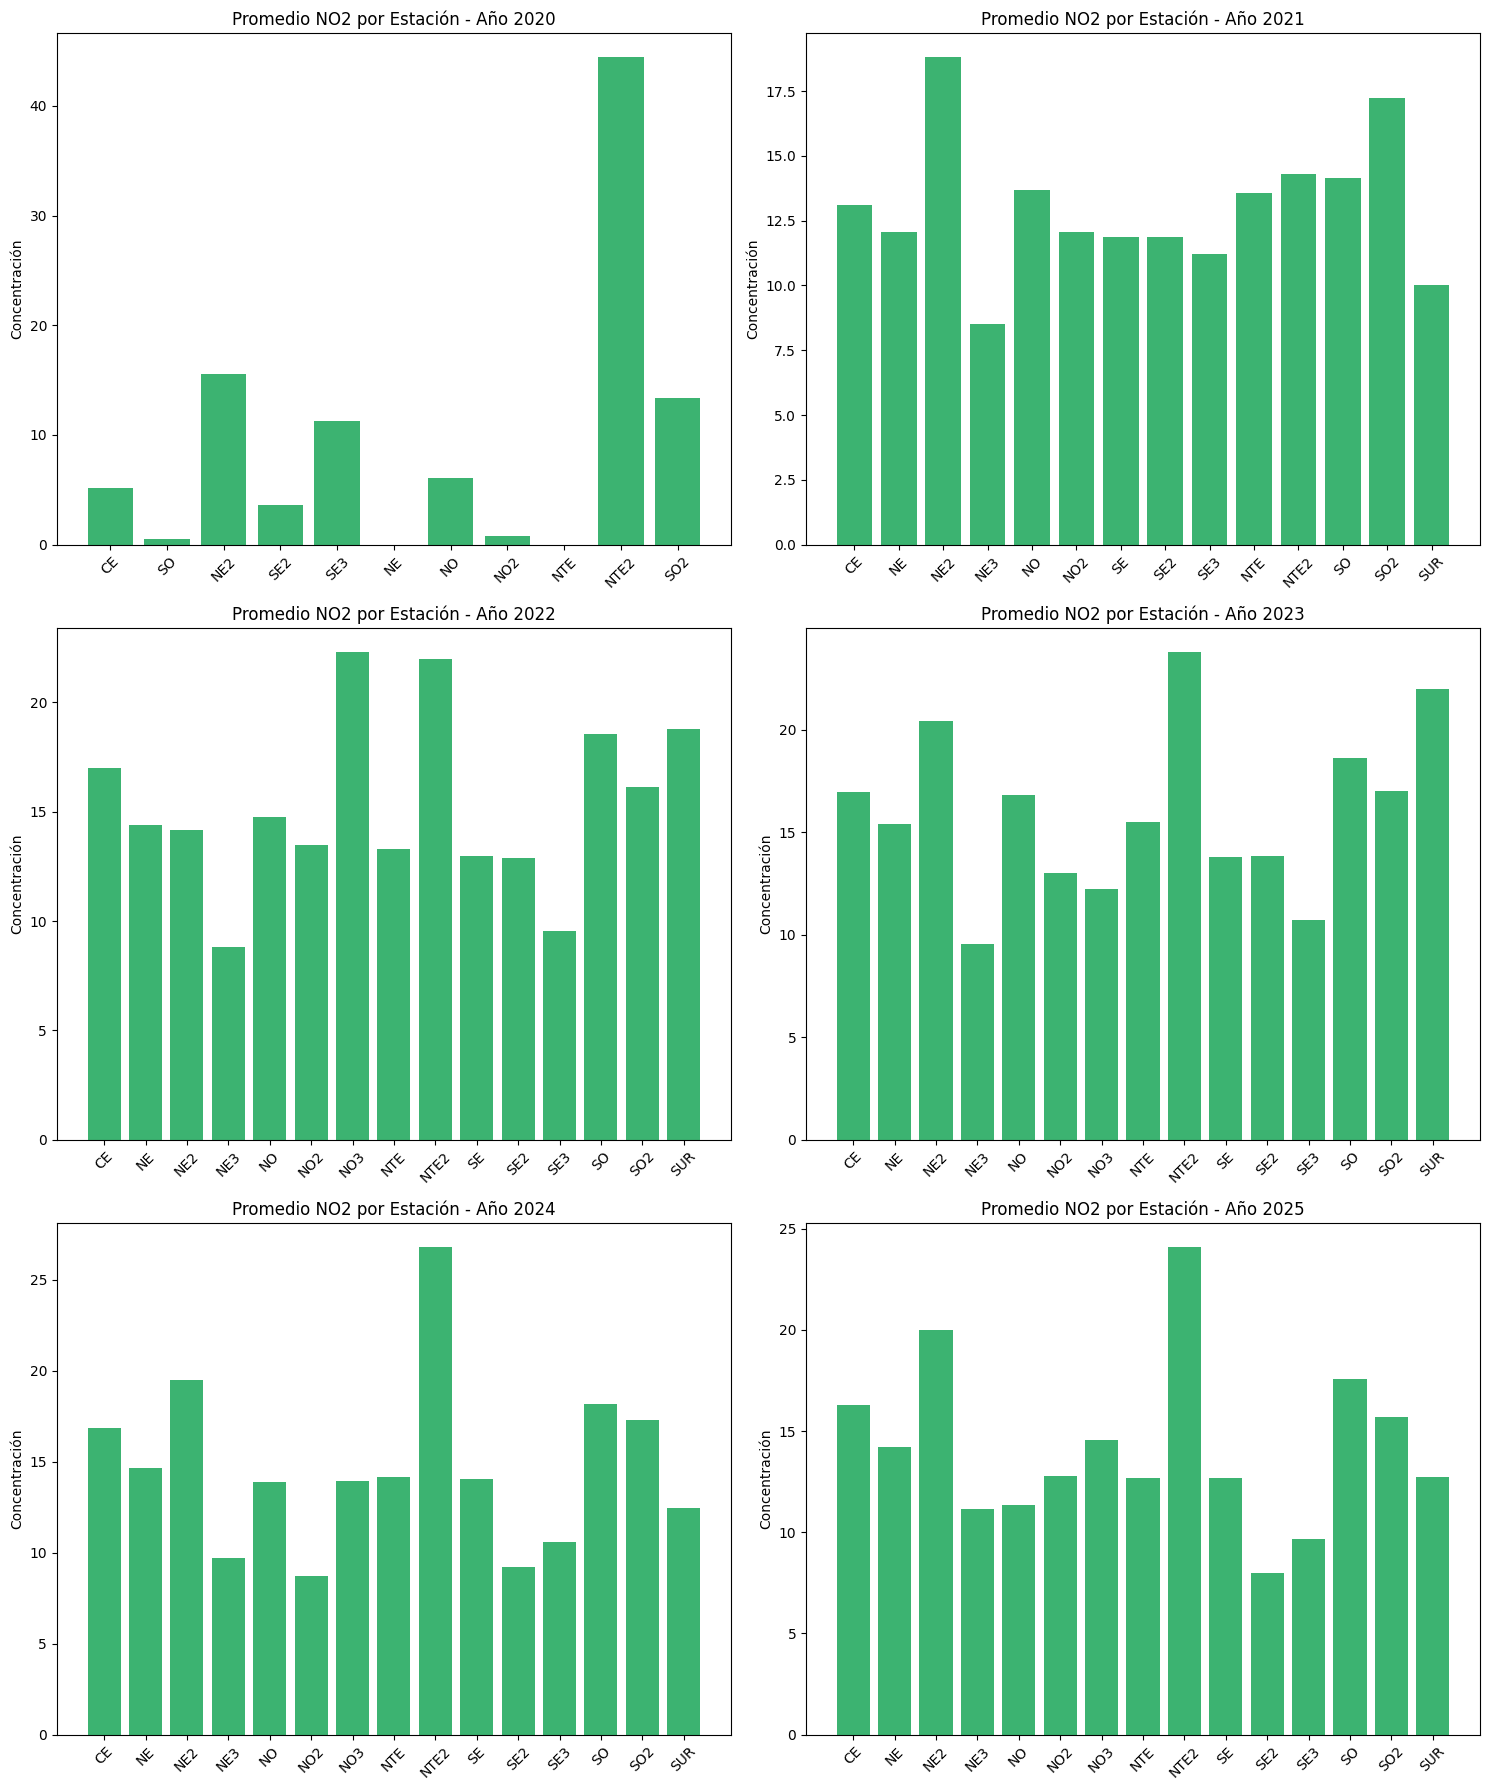

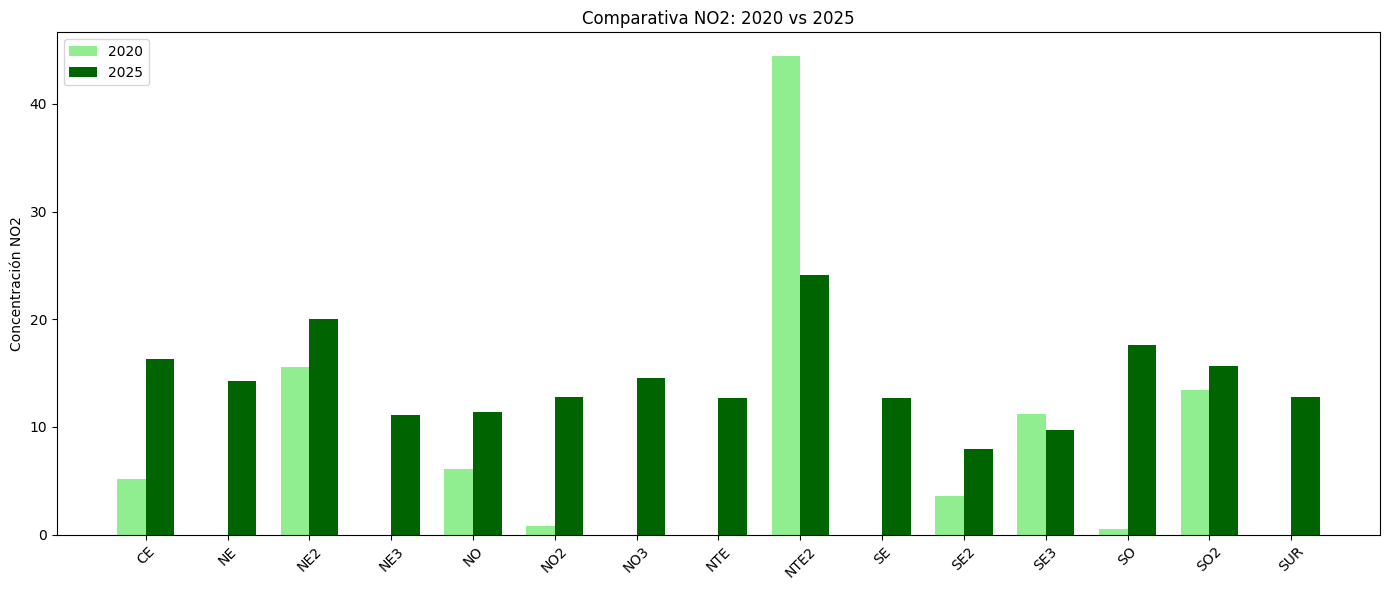

--- Generando visualizaciones para NOX ---


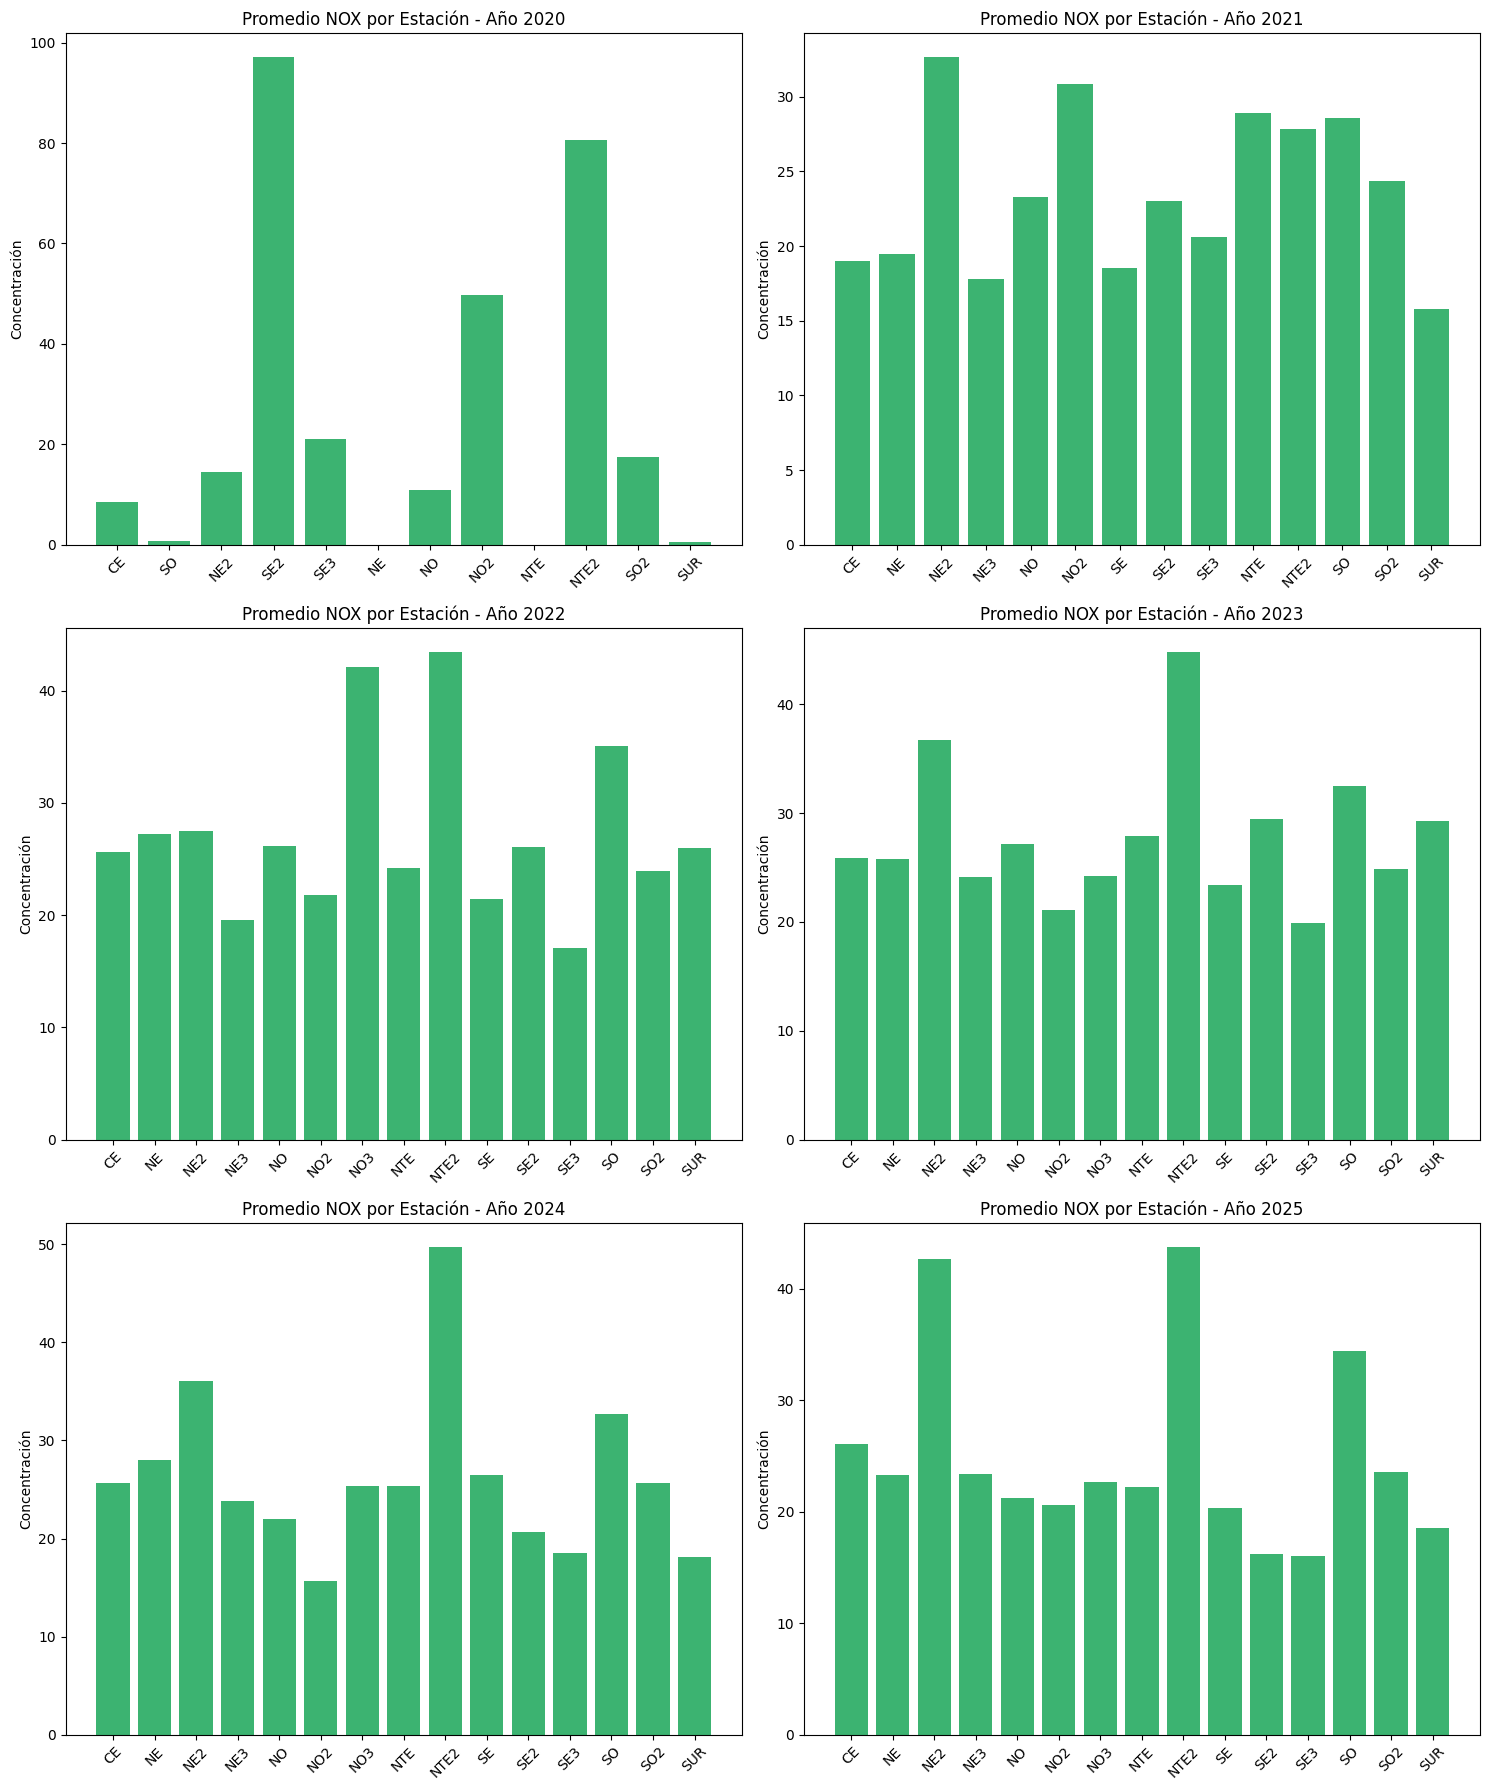

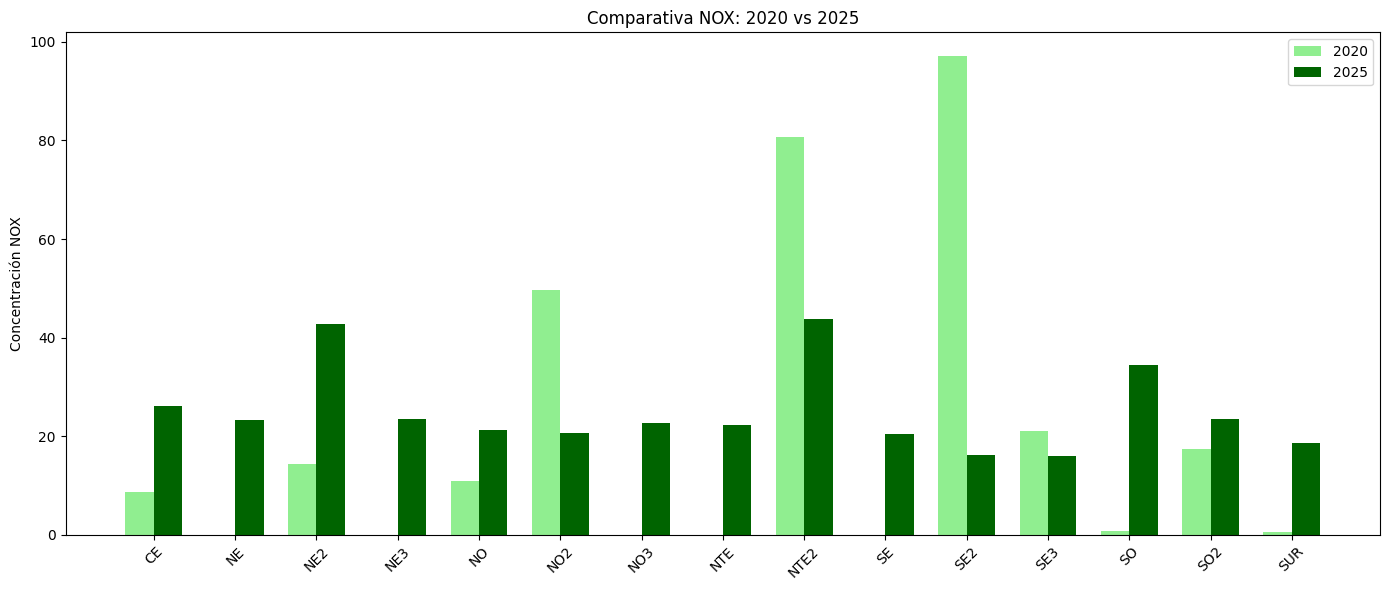

--- Generando visualizaciones para O3 ---


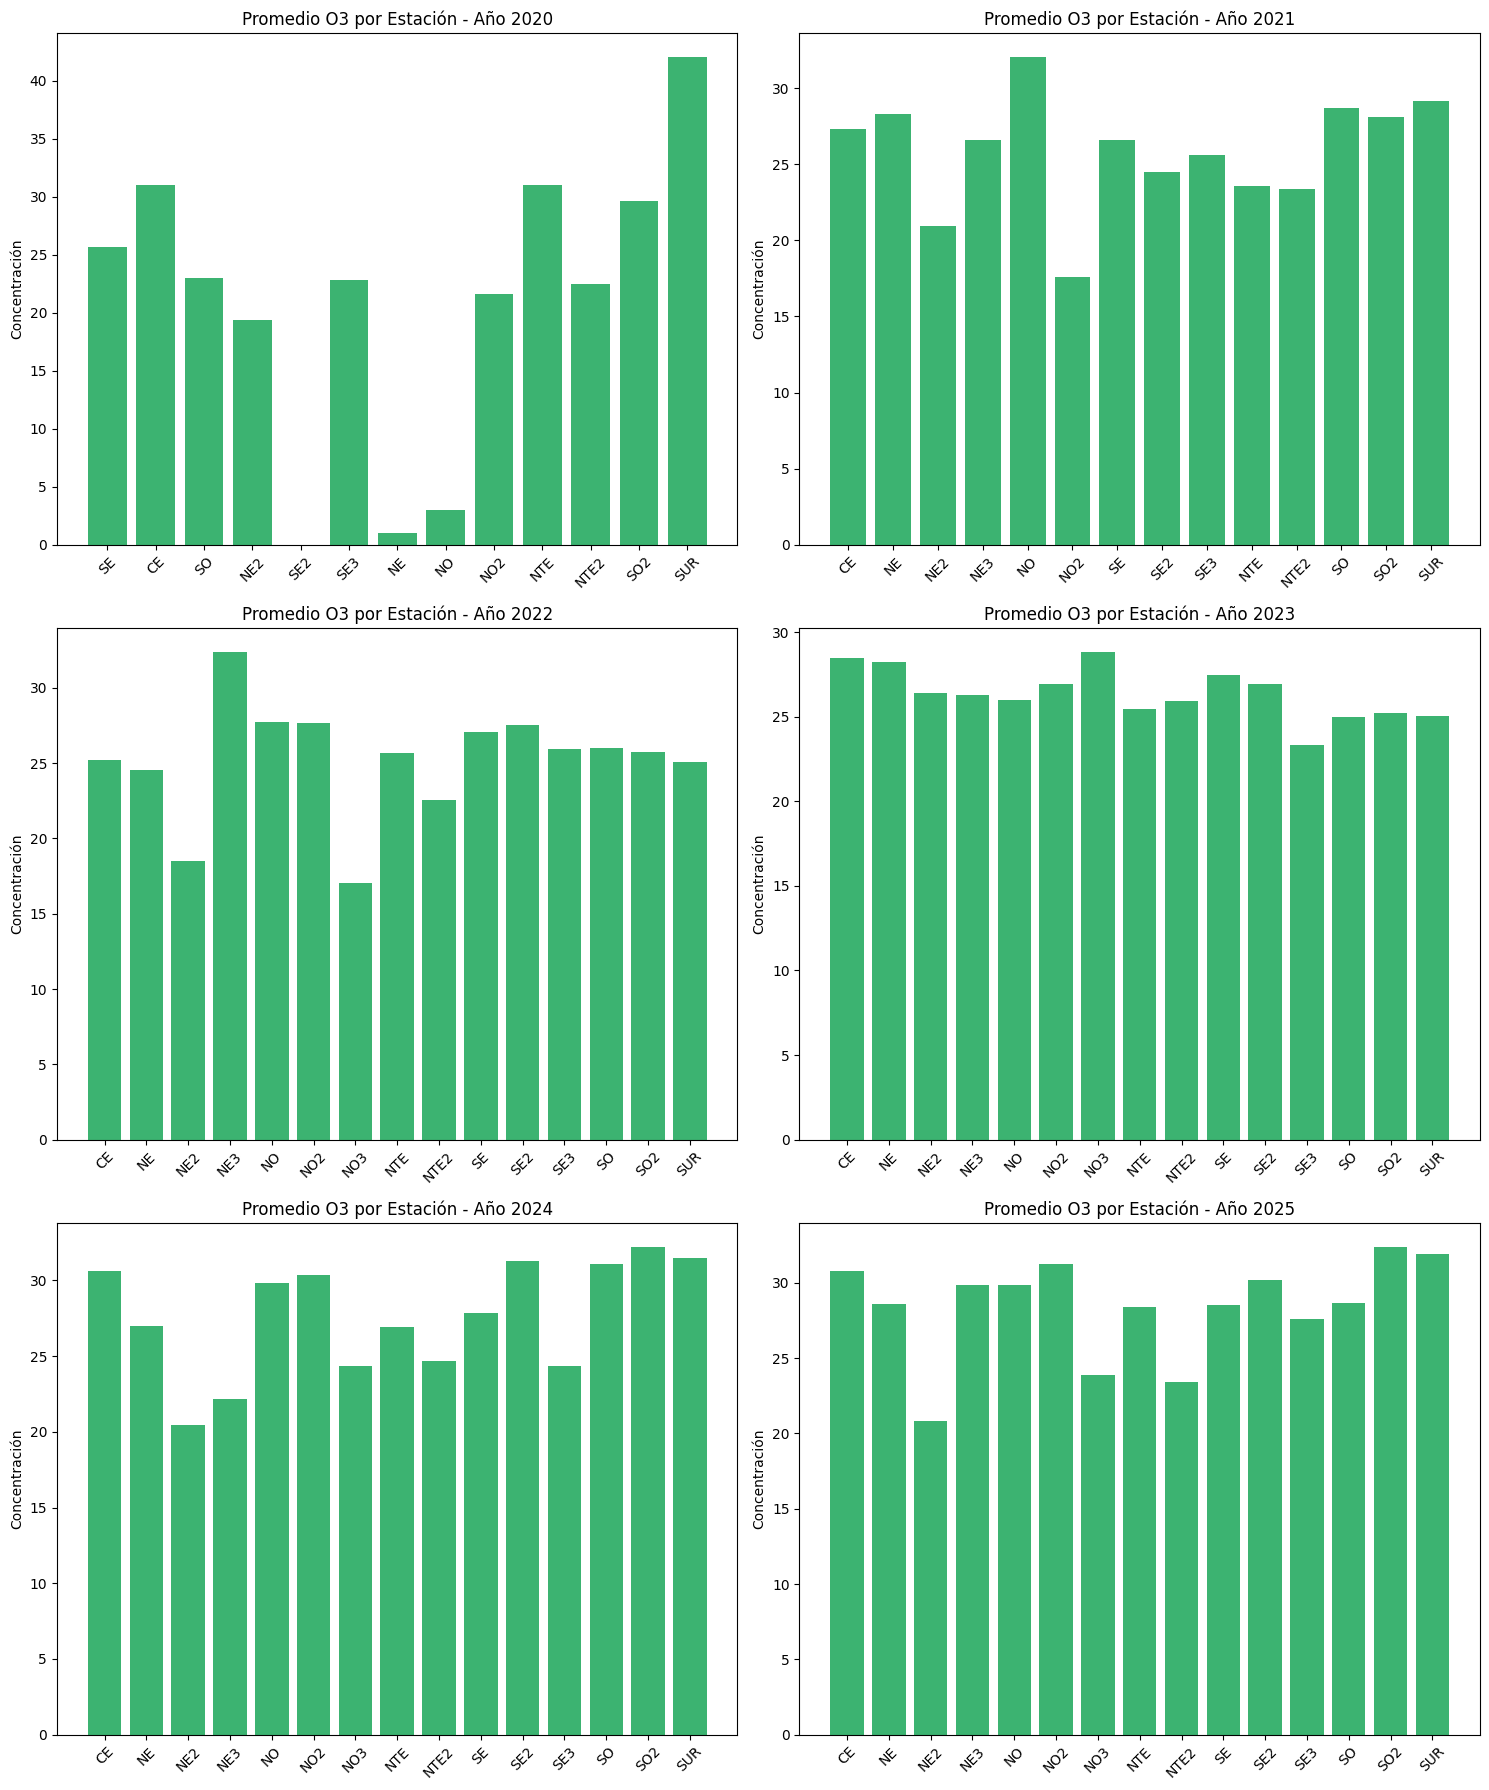

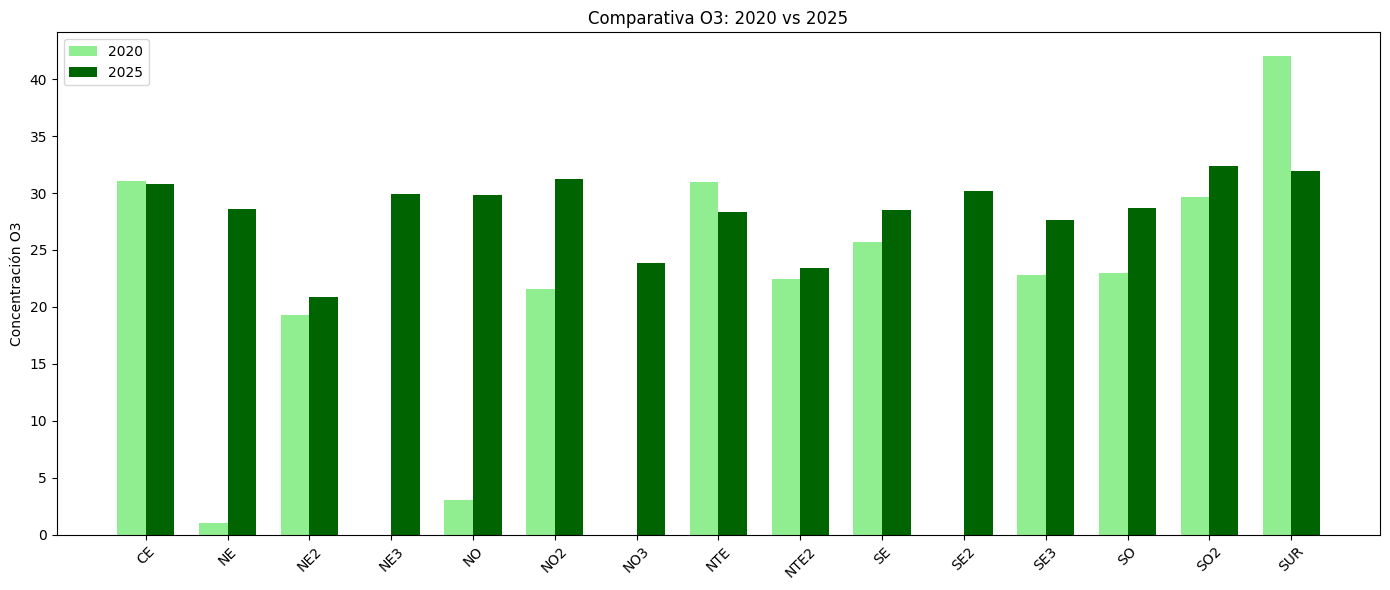

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Lista de contaminantes adicionales solicitados
pollutants = ['PM2.5','PM10','SO2', 'CO', 'NO', 'NO2', 'NOX', 'O3']
years = [2020, 2021, 2022, 2023, 2024, 2025]
year_start = 2020
year_end = 2025

# Verificar si datos_sima existe antes de proceder
if 'datos_sima' not in globals() or not datos_sima:
    print("Error: La variable 'datos_sima' no está definida o está vacía. Por favor, ejecuta las celdas de procesamiento de datos primero.")
else:
    for pol in pollutants:
        # 1. Gráficas Anuales (Promedio por estación)
        fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
        axes = axes.flatten()
        print(f"--- Generando visualizaciones para {pol} ---")

        for i, year in enumerate(years):
            if year in datos_sima:
                estaciones = list(datos_sima[year].keys())
                # Filtrar estaciones que tengan la columna del contaminante actual
                nombres_estaciones = [est for est in estaciones if pol in datos_sima[year][est].columns]
                promedios = [datos_sima[year][est][pol].mean() for est in nombres_estaciones]

                if promedios:
                    axes[i].bar(nombres_estaciones, promedios, color='mediumseagreen')
                axes[i].set_title(f'Promedio {pol} por Estación - Año {year}')
                axes[i].set_ylabel('Concentración')
                axes[i].tick_params(axis='x', rotation=45)
            else:
                axes[i].set_title(f'Datos {year} no disponibles')

        plt.tight_layout()
        plt.show()

        # 2. Comparativa 2020 vs 2025
        estaciones_2020 = set(datos_sima[year_start].keys()) if year_start in datos_sima else set()
        estaciones_2025 = set(datos_sima[year_end].keys()) if year_end in datos_sima else set()
        todas_est = sorted(list(estaciones_2020.union(estaciones_2025)))

        labels, p_start, p_end = [], [], []
        for est in todas_est:
            v_start = datos_sima[year_start][est][pol].mean() if (year_start in datos_sima and est in datos_sima[year_start] and pol in datos_sima[year_start][est].columns) else np.nan
            v_end = datos_sima[year_end][est][pol].mean() if (year_end in datos_sima and est in datos_sima[year_end] and pol in datos_sima[year_end][est].columns) else np.nan

            if not (np.isnan(v_start) and np.isnan(v_end)):
                labels.append(est)
                p_start.append(v_start)
                p_end.append(v_end)

        if labels:
            x = np.arange(len(labels))
            width = 0.35
            fig_comp, ax_comp = plt.subplots(figsize=(14, 6))
            ax_comp.bar(x - width/2, p_start, width, label=str(year_start), color='lightgreen')
            ax_comp.bar(x + width/2, p_end, width, label=str(year_end), color='darkgreen')
            ax_comp.set_ylabel(f'Concentración {pol}')
            ax_comp.set_title(f'Comparativa {pol}: {year_start} vs {year_end}')
            ax_comp.set_xticks(x)
            ax_comp.set_xticklabels(labels, rotation=45)
            ax_comp.legend()
            plt.tight_layout()
            plt.show()

Como pudimos observar en las gráficas creadas, hay estaciones donde en algunos años no hay registros para ciertas partículas, este fenómeno se presenta más comúnmente para las partículas PM2.5, lo que es indicio de que, en algunas estaciones hubo años completos donde el sensor que se encargaba de detectar determinada partícula estuvo inactivo en la determinada estación de monitoreo, ya sea por mantenimiento o porque no funcionaba del todo. Por ello checaremos en concreto todas las filas nulas, para ver qué sensores que detestaban qué partículas estuviaron inactivos en qué años en cuáles estaciones.